**Import modules**

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import zipfile as zf
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print('Done importing modules...')

Done importing modules...


In [15]:
# # unzip file

# zip_path = '../data/Python_Diwali_Sales_Analysis.zip'
# extract_path = '../data/'

# with zf.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

In [16]:
# create df
file_path = r'../data/Python_Diwali_Sales_Analysis/Diwali Sales Data.csv'

df = pd.read_csv(file_path, encoding='unicode_escape')

print('Done creating dataframe...')

Done creating dataframe...


**Initial Look at the Data**

**Initial Observation:**

- The dataset contains **11,251 rows and 15 columns.** Missing values are pressent in `Amount`, `Status`, and `unnamed1`. However, it appears that the `Status` and `unnamed1` columns do not have any entry in the dataset.

In [17]:
# df shape
row, col = df.shape

print(f'Number of Rows: {row}')
print(f'Number of Columns: {col}')

# df metadata
df.info()

Number of Rows: 11251
Number of Columns: 15
<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


In [18]:
# first 5 rows
print('First 5 rows: ')
display(df.head())

# last 5 rows
print('\nLast 5 rows: ')
display(df.tail())

First 5 rows: 


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,"23,952.00",NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,"23,934.00",NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,"23,924.00",NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,"23,912.00",NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,"23,877.00",NaN,NaN



Last 5 rows: 


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.00,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.00,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.00,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.00,NaN,NaN
11250,1002744,Brumley,P00281742,F,18-25,19,0,Maharashtra,Western,Healthcare,Office,3,188.00,NaN,NaN


In [19]:
# count unique values
df.nunique().sort_values(ascending=False)

Amount              6584
User_ID             3755
Product_ID          2351
Cust_name           1250
Age                   81
Product_Category      18
State                 16
Occupation            15
Age Group              7
Zone                   5
Orders                 4
Marital_Status         2
Gender                 2
Status                 0
unnamed1               0
dtype: int64

In [20]:
# descriptive stats for numerical columns
pd.set_option('display.float_format', '{:,.2f}'.format)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
User_ID,"11,251.00","1,003,004.49","1,716.13","1,000,001.00","1,001,492.00","1,003,065.00","1,004,430.00","1,006,040.00"
Age,"11,251.00",35.42,12.75,12.00,27.00,33.00,43.00,92.00
Marital_Status,"11,251.00",0.42,0.49,0.00,0.00,0.00,1.00,1.00
Orders,"11,251.00",2.49,1.12,1.00,1.50,2.00,3.00,4.00
Amount,"11,239.00","9,453.61","5,222.36",188.00,"5,443.00","8,109.00","12,675.00","23,952.00"
Status,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unnamed1,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Initial Observation:**

* **Age:** The average customer age is **35.42 years**, with a standard deviation of **12.75 years**, indicating considerable variation in customer ages. The median age is **33 years**, meaning that 50% of the customers are aged 33 or below, while the middle 50% of customers are between **27 and 43 years old**. Customer ages range from **12 to 92 years**. Since the mean is higher than the median, the distribution may be **right-skewed**, potentially due to a smaller number of older customers. This should be further examined using a histogram and boxplot.

* **Marital_Status:** The mean value is **0.42**, with a standard deviation of **0.49**. Because this feature is binary, with **0 representing unmarried and 1 representing married customers**, the mean can be interpreted as the proportion of observations coded as 1, approximately **42%**. The median is **0**, while the 75th percentile is **1**, indicating that at least 50% but fewer than 75% of the observations have a value of 0. Since this is a categorical binary variable, skewness is not particularly useful for interpretation. The actual proportions of each category should instead be examined using frequency counts.

* **Orders:** The average number of orders is **2.49**, with a standard deviation of **1.12**, indicating some variation in the number of orders across the records. The median is **2**, meaning that half of the records have 2 or fewer orders and half have 2 or more orders. The middle 50% of observations fall between **1.5 and 3 orders**, while the values range from **1 to 4 orders**. Since `Orders` is a discrete count variable with only four possible values, its distribution would be more appropriately examined using frequency counts or a bar chart.

* **Amount:** The average transaction amount is **9,453.61**, with a standard deviation of **5,222.36**, indicating considerable variation in transaction amounts. The median is **8,109**, which is lower than the mean and suggests that the distribution may be **right-skewed**, with some transactions having relatively high values. The middle 50% of transaction amounts range from **5,443 to 12,675**, while the values range from **188 to 23,952**. A histogram and boxplot should be used to further examine the distribution and identify potential outliers.

* **User_ID:** The `User_ID` values range from **1,000,001 to 1,006,040**. Since this column serves as an identifier rather than a meaningful numerical measurement, its mean, standard deviation, and percentiles do not provide useful analytical insight. It should therefore be excluded from numerical distribution analysis.

* **Status and unnamed1:** Both columns contain **0 non-null values**, meaning they are completely empty. They provide no usable information for the analysis and can be removed during data cleaning.

In [21]:
# descriptive stats for categorical columns
df.describe(include='object').T.sort_values(by ='freq', ascending=False)

,count,unique,top,freq
Gender,11251,2,F,7842
Age Group,11251,7,26-35,4543
Zone,11251,5,Central,4296
Product_Category,11251,18,Clothing & Apparel,2655
State,11251,16,Uttar Pradesh,1946
Occupation,11251,15,IT Sector,1588
Product_ID,11251,2351,P00265242,53
Cust_name,11251,1250,Vishakha,42


**Exploratory Data Analysis**

In [22]:
# to prevent alteration
df_copy = df.copy()

# drop status and unnamed1 columns
df_copy = df_copy.drop(columns=['Status', 'unnamed1'])
print('Successfully dropped columns... \n')

# display df copy's metadata
display(df_copy.info())

Successfully dropped columns... 

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), str(8)
memory usage: 1.1 MB


None

In [23]:
# inspect data types
df_copy.dtypes

User_ID               int64
Cust_name               str
Product_ID              str
Gender                  str
Age Group               str
Age                   int64
Marital_Status        int64
State                   str
Zone                    str
Occupation              str
Product_Category        str
Orders                int64
Amount              float64
dtype: object

In [24]:
# Inspect fractional components of Amount
print('Fractional components in Amount:')
display(df_copy['Amount'].dropna().mod(1).value_counts().sort_index())
print('\n' + "=====" * 10)


# Count Amount values with a fractional component
decimal_amounts = df_copy['Amount'].dropna()[df_copy['Amount'].dropna() % 1 != 0]

print(f'\nNumber of decimal values: {len(decimal_amounts)}')
print(f'Percentage: {len(decimal_amounts) / df_copy["Amount"].notna().sum() * 100:.2f}%')

Fractional components in Amount:


Amount
0.00    11234
0.45        1
0.50        2
0.99        2
Name: count, dtype: int64



Number of decimal values: 5
Percentage: 0.04%


**Initial Observation:**

* **Age Group:** The feature is currently stored as an `object` data type. Since it represents categorical age ranges, it will be treated as a categorical feature and can be used to analyze customer demographics and purchasing behavior across age groups.

* **Amount:** The feature is stored as `float64`. The vast majority of values are whole numbers, with only 5 out of 11,239 non-null values containing decimal components (0.04%). Since these values are non-null observations and there is no evidence that the decimal values are invalid, the original values will be retained without conversion or rounding to avoid altering the data.

* **Status and unnamed1:** Both features contained no data points (0 non-null values) and provided no usable information for the analysis. These columns were therefore removed from the dataset.


**Data Quality**

In [25]:
# check if df has duplicates
has_duplicates = df_copy.duplicated().any()
print(f'Are there duplicates in the dataset?: {has_duplicates}')

duplicate_count = df_copy.duplicated().sum()
print(f'Number of duplicates: {duplicate_count}')

Are there duplicates in the dataset?: True
Number of duplicates: 8


In [26]:
# inspect duplicates
df_copy[df_copy.duplicated()]

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
19,1001883,Praneet,P00029842,M,51-55,54,1,Uttar Pradesh,Central,Hospitality,Auto,1,"23,568.00"
4404,1004725,Jackson,P00150842,F,36-45,37,1,Maharashtra,Western,Hospitality,Electronics & Gadgets,4,"9,859.00"
5703,1003208,Bowman,P00171642,F,26-35,31,0,Bihar,Eastern,Agriculture,Electronics & Gadgets,4,"8,088.00"
5908,1001260,Dheeraj,P00344042,M,26-35,28,0,Maharashtra,Western,IT Sector,Electronics & Gadgets,4,"8,015.00"
6173,1001325,Reese,P00111742,F,26-35,27,1,Gujarat,Western,Construction,Electronics & Gadgets,3,"7,923.00"
8651,1000083,Gute,P00242842,M,26-35,35,0,Uttar Pradesh,Central,Hospitality,Clothing & Apparel,3,"5,345.00"
8941,1001476,Anudeep,P00036842,M,18-25,25,0,Maharashtra,Western,IT Sector,Clothing & Apparel,4,"5,202.00"
10571,1004404,Rittenbach,P00150142,F,26-35,28,1,Haryana,Northern,Aviation,Electronics & Gadgets,3,"2,304.00"


In [27]:
# Display duplicate rows
# show all instances
duplicates = df[df.duplicated(keep=False)]

display(duplicates)

print("=====" * 10)
print(f"Number of duplicated rows: {len(duplicates)}")

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
18,1001883,Praneet,P00029842,M,51-55,54,1,Uttar Pradesh,Central,Hospitality,Auto,1,"23,568.00",NaN,NaN
19,1001883,Praneet,P00029842,M,51-55,54,1,Uttar Pradesh,Central,Hospitality,Auto,1,"23,568.00",NaN,NaN
4403,1004725,Jackson,P00150842,F,36-45,37,1,Maharashtra,Western,Hospitality,Electronics & Gadgets,4,"9,859.00",NaN,NaN
4404,1004725,Jackson,P00150842,F,36-45,37,1,Maharashtra,Western,Hospitality,Electronics & Gadgets,4,"9,859.00",NaN,NaN
5702,1003208,Bowman,P00171642,F,26-35,31,0,Bihar,Eastern,Agriculture,Electronics & Gadgets,4,"8,088.00",NaN,NaN
5703,1003208,Bowman,P00171642,F,26-35,31,0,Bihar,Eastern,Agriculture,Electronics & Gadgets,4,"8,088.00",NaN,NaN
5907,1001260,Dheeraj,P00344042,M,26-35,28,0,Maharashtra,Western,IT Sector,Electronics & Gadgets,4,"8,015.00",NaN,NaN
5908,1001260,Dheeraj,P00344042,M,26-35,28,0,Maharashtra,Western,IT Sector,Electronics & Gadgets,4,"8,015.00",NaN,NaN
6172,1001325,Reese,P00111742,F,26-35,27,1,Gujarat,Western,Construction,Electronics & Gadgets,3,"7,923.00",NaN,NaN
6173,1001325,Reese,P00111742,F,26-35,27,1,Gujarat,Western,Construction,Electronics & Gadgets,3,"7,923.00",NaN,NaN


Number of duplicated rows: 16


In [28]:
# remove duplicates
df_copy = df_copy.drop_duplicates()
print('Successfully dropped duplicates in the dataframe copy... \n')

# display update
print(f'\nRows after removing duplicates: {len(df_copy)}')
print(f'Remaining duplicate rows: {df_copy.duplicated().sum()}')

Successfully dropped duplicates in the dataframe copy... 


Rows after removing duplicates: 11243
Remaining duplicate rows: 0


**Remarks:**

Duplicate Records: The dataset initially contained 8 duplicate occurrences, representing 16 rows in 8 identical pairs. The duplicated records were verified by comparing all columns and confirmed to be exact duplicates. The duplicate rows were removed to prevent the same transactions from being counted more than once during analysis.

In [29]:
# Inspect missing/null values
print('Check whether each column has missing/null values:')
print(df_copy.isnull().any().sort_values(ascending=False))

print("=====" * 10)

print('Check the number of missing/null values per column:')
print(df_copy.isnull().sum().sort_values(ascending=False))

Check whether each column has missing/null values:
Amount               True
User_ID             False
Cust_name           False
Product_ID          False
Gender              False
Age Group           False
Age                 False
Marital_Status      False
State               False
Zone                False
Occupation          False
Product_Category    False
Orders              False
dtype: bool
Check the number of missing/null values per column:
Amount              12
Cust_name            0
Product_ID           0
Gender               0
User_ID              0
Age Group            0
Age                  0
State                0
Marital_Status       0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
dtype: int64


In [30]:
# dipslay columns with missing/null values
missing = df_copy[df_copy.isnull().any(axis=1)]
missing

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN
14,1003858,Cano,P00293742,M,46-50,46,1,Madhya Pradesh,Central,Hospitality,Auto,3,NaN
16,1005447,Amy,P00275642,F,46-50,48,1,Andhra Pradesh,Southern,IT Sector,Auto,3,NaN
109,1005265,Sakshi,P00296242,F,46-50,48,1,Delhi,Central,Banking,Footwear & Shoes,1,NaN
111,1005261,Apoorva,P00057942,F,36-45,41,1,Delhi,Central,IT Sector,Footwear & Shoes,2,NaN
184,1005538,Kartik,P00269542,F,46-50,49,1,Karnataka,Southern,Banking,Footwear & Shoes,1,NaN
293,1000326,Jonathan,P00120542,M,51-55,53,0,Gujarat,Western,IT Sector,Footwear & Shoes,3,NaN
344,1002507,Lakshmi,P00045842,F,26-35,35,1,Gujarat,Western,Chemical,Furniture,1,NaN
345,1004498,Srishti,P00030842,F,51-55,55,0,Delhi,Central,Textile,Footwear & Shoes,1,NaN
452,1004601,Gaurav,P00014442,F,36-45,40,1,Madhya Pradesh,Central,Hospitality,Food,4,NaN


In [31]:
# inspect median
amount_by_group = df_copy.groupby(
    ['Product_Category', 'Occupation']
)['Amount'].median().unstack()


display(amount_by_group)

Occupation,Agriculture,Automobile,Aviation,Banking,Chemical,Construction,Food Processing,Govt,Healthcare,Hospitality,IT Sector,Lawyer,Media,Retail,Textile
Product_Category,,,,,,,,,,,,,,,
Auto,"18,609.00","23,413.50","23,193.00","21,099.50",NaN,"21,172.00","23,239.00","18,970.50","18,995.00","18,679.00","19,295.00","16,738.00","20,939.50","21,200.00","19,280.00"
Beauty,"4,542.50","5,946.00","4,635.00","4,567.50","4,588.00","5,939.00","4,525.00","4,586.00","4,596.00","4,553.00","4,567.00","4,515.00","4,603.50","5,901.00","6,005.00"
Books,"10,240.00","10,364.00","10,301.00","10,329.00","10,521.00","10,570.00","10,262.00","12,844.00","10,609.00","9,280.50","10,599.00","10,225.00","9,206.50","10,232.00","11,650.00"
Clothing & Apparel,"6,976.00","6,947.50","6,923.00","6,924.00","6,940.50","6,889.00","6,912.00","6,887.00","6,942.00","6,885.00","6,925.00","6,884.00","6,898.00","6,915.00","6,890.00"
Decor,"7,028.50","9,908.00","7,009.50","8,036.50","7,797.50","6,122.00","7,912.00","6,040.00","8,032.00","8,046.00","7,888.00","6,111.00","6,980.00","5,835.00","9,989.00"
Electronics & Gadgets,"7,893.50","7,909.50","7,865.00","7,939.00","7,961.00","6,975.00","7,917.50","7,884.00","7,905.50","7,884.50","7,912.00","7,980.00","7,968.50","7,774.00","7,848.00"
Food,"13,655.00","15,289.00","15,275.00","15,227.00","15,246.00","15,273.00","12,013.00","15,247.00","15,236.00","12,040.00","15,234.00","15,201.50","15,251.00","15,235.00","15,296.50"
Footwear & Shoes,"12,758.00","16,456.00","16,415.50","16,356.00","16,495.00","12,854.00","16,448.00","16,283.00","12,823.00","12,790.50","16,197.00","14,510.50","16,420.50","16,543.50","16,550.00"
Furniture,"16,456.00","16,051.00","15,952.00","16,163.00","16,533.00","16,349.00","18,267.00","16,649.50","16,072.50","16,357.00","16,376.00","16,075.00","16,071.50","16,435.00","14,401.50"


In [32]:
category_medians = df_copy.groupby('Product_Category')['Amount'].median()


display(
    category_medians.loc[
        ['Auto', 'Footwear & Shoes', 'Furniture', 'Food']
    ]
)

Product_Category
Auto               19,287.50
Footwear & Shoes   16,289.00
Furniture          16,277.50
Food               15,232.00
Name: Amount, dtype: float64

In [33]:
# identify rows where amount is missing
missing_amount = df_copy[df_copy['Amount'].isnull()].copy()

# calculate the median amount for each Product Category
# and use it to propose a replacement value for each missing Amount
missing_amount['Proposed_Amount'] = (
    missing_amount['Product_Category']
    .map(df_copy.groupby('Product_Category')['Amount'].median())
)

# Display the missing Amount values alongside their proposed replacements
display(
    missing_amount[
        ['Product_Category', 'Occupation', 'Orders', 'Amount', 'Proposed_Amount']
    ]
)

,Product_Category,Occupation,Orders,Amount,Proposed_Amount
7,Auto,IT Sector,1,NaN,"19,287.50"
14,Auto,Hospitality,3,NaN,"19,287.50"
16,Auto,IT Sector,3,NaN,"19,287.50"
109,Footwear & Shoes,Banking,1,NaN,"16,289.00"
111,Footwear & Shoes,IT Sector,2,NaN,"16,289.00"
184,Footwear & Shoes,Banking,1,NaN,"16,289.00"
293,Footwear & Shoes,IT Sector,3,NaN,"16,289.00"
344,Furniture,Chemical,1,NaN,"16,277.50"
345,Footwear & Shoes,Textile,1,NaN,"16,289.00"
452,Food,Hospitality,4,NaN,"15,232.00"


**Remarks:**

Upon inspecting the missing values and their related information, the 12 missing values in the `Amount` column will be imputed using the median `Amount` of their respective `Product_Category`.


In [34]:
# perform imputation on missing values
df_copy['Amount'] = df_copy['Amount'].fillna(
    df_copy['Product_Category'].map(category_medians)
)

print('Missing Amount values after imputation:')
print(df_copy['Amount'].isnull().sum())

Missing Amount values after imputation:
0


In [35]:
# verify 12 rows after imputation
display(
    df_copy.loc[
        missing_amount.index,
        ['Product_Category', 'Occupation', 'Orders', 'Amount']
    ]
)

,Product_Category,Occupation,Orders,Amount
7,Auto,IT Sector,1,"19,287.50"
14,Auto,Hospitality,3,"19,287.50"
16,Auto,IT Sector,3,"19,287.50"
109,Footwear & Shoes,Banking,1,"16,289.00"
111,Footwear & Shoes,IT Sector,2,"16,289.00"
184,Footwear & Shoes,Banking,1,"16,289.00"
293,Footwear & Shoes,IT Sector,3,"16,289.00"
344,Furniture,Chemical,1,"16,277.50"
345,Footwear & Shoes,Textile,1,"16,289.00"
452,Food,Hospitality,4,"15,232.00"


**Numerical Univariate Analysis**

- This section aims to understand the distribution, central tendency, variability, and potential outliers of the dataset's numerical features. Each variable will be analyzed individually using descriptive statistics and appropriate visualizations to identify notable patterns and characteristics in the data.


In [37]:
# descriptive stats for numerical variables
num_cols = df_copy[[
    'Age',
    'Orders',
    'Amount',
    'Marital_Status'
]]


summary = pd.DataFrame(
    {
        'Mean': num_cols.mean(),
        'Median': num_cols.median(),
        'Mode': num_cols.mode().iloc[0],
        'Variance': num_cols.var(),
        'Standard Deviation': num_cols.std(),
        'Minimum': num_cols.min(),
        'Maximum': num_cols.max(),
        'Range': num_cols.max() - num_cols.min(),
        'Skewness': num_cols.skew()
    }
)

display((summary).round(2))

,Mean,Median,Mode,Variance,Standard Deviation,Minimum,Maximum,Range,Skewness
Age,35.42,33.00,30.00,162.72,12.76,12.00,92.00,80.00,1.18
Orders,2.49,2.00,2.00,1.24,1.11,1.00,4.00,3.00,0.02
Amount,"9,461.90","8,111.00","7,907.00","27,296,917.23","5,224.65",188.00,"23,952.00","23,764.00",0.55
Marital_Status,0.42,0.00,0.00,0.24,0.49,0.00,1.00,1.00,0.32


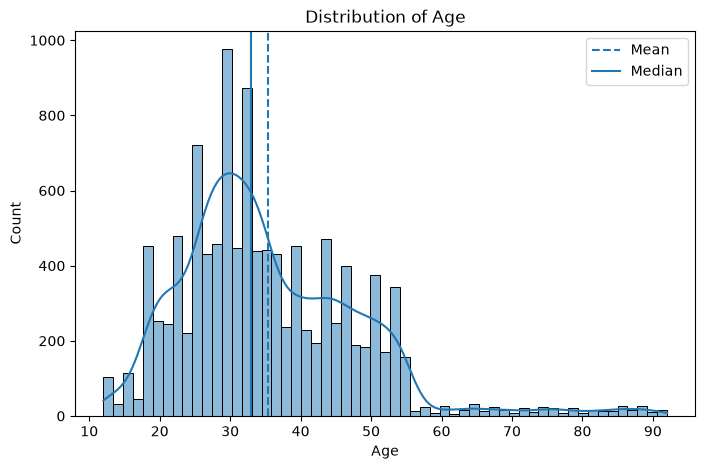

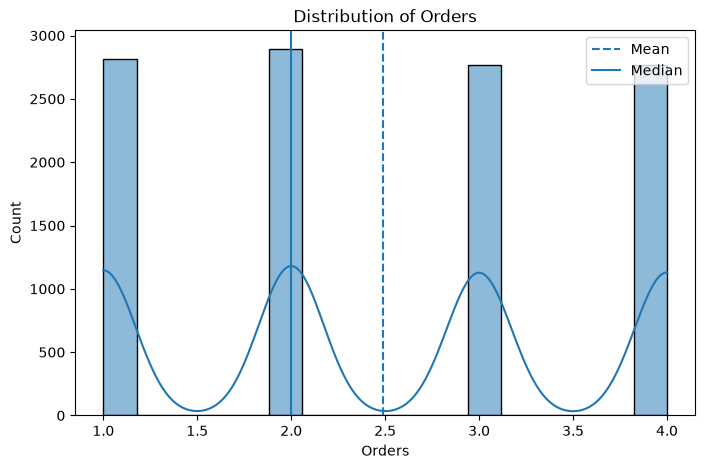

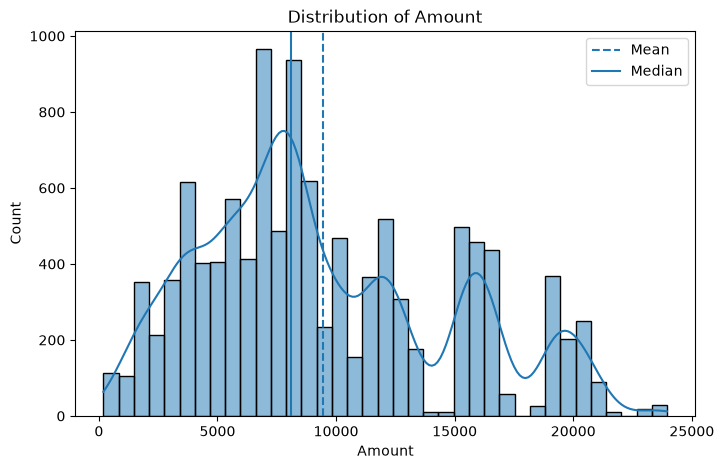

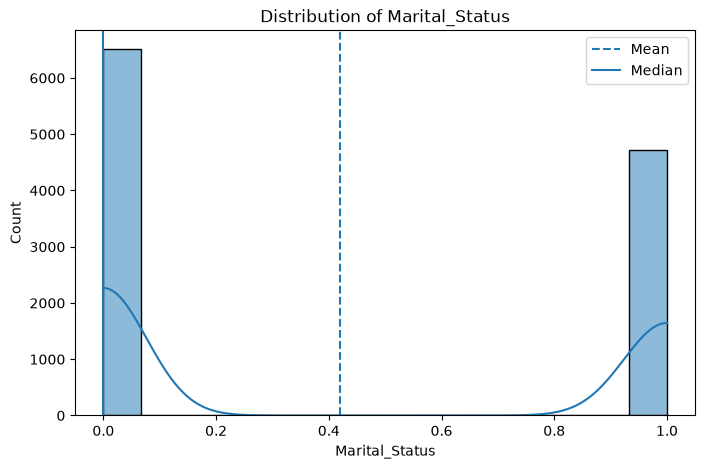

In [36]:
# plot histogram
num_cols = [
    'Age',
    'Orders',
    'Amount',
    'Marital_Status'
]

for col in num_cols:

  plt.figure(figsize=(8,5))

  sns.histplot(data=df_copy, x=col, kde=True)

  plt.axvline(df_copy[col].mean(), linestyle='--', label='Mean')
  plt.axvline(df_copy[col].median(), linestyle='-', label='Median')

  plt.title(f'Distribution of {col}')
  plt.legend()
  plt.show()

In [38]:
# identifying outliers
def main():

  identify_outliers()


def identify_outliers():

  q1 = num_cols.quantile(0.25)
  q3 = num_cols.quantile(0.75)

  iqr = q3 - q1

  lower_limit = q1 - 1.5 * iqr
  upper_limit = q3 + 1.5 * iqr

  for col in num_cols:

    lower_outliers = num_cols[col][num_cols[col] < lower_limit[col]]

    upper_outliers = num_cols[col][num_cols[col] > upper_limit[col]]

    print(f'\n {col}')

    print(f'Lower Limit: {lower_limit[col]}')
    print(f'Lower Outliers: {lower_outliers.tolist()}')


    print(f'Upper Limit: {upper_limit[col]}')
    print(f'Upper Outliers: {upper_outliers.tolist()}')


main()


 Age
Lower Limit: 3.0
Lower Outliers: []
Upper Limit: 67.0
Upper Outliers: [83, 72, 72, 83, 77, 87, 79, 71, 88, 88, 72, 82, 87, 92, 72, 71, 90, 92, 90, 75, 82, 71, 81, 73, 84, 76, 82, 86, 92, 87, 89, 68, 87, 91, 77, 85, 76, 68, 81, 75, 82, 70, 81, 90, 77, 87, 91, 80, 76, 73, 75, 74, 79, 89, 69, 79, 86, 75, 85, 70, 78, 72, 79, 80, 85, 82, 82, 88, 80, 76, 77, 90, 74, 78, 87, 92, 69, 69, 79, 74, 68, 92, 74, 72, 81, 69, 75, 88, 83, 90, 84, 86, 70, 75, 78, 89, 83, 88, 76, 85, 89, 80, 68, 82, 80, 88, 70, 84, 84, 83, 68, 88, 76, 90, 85, 84, 78, 85, 77, 89, 86, 76, 76, 89, 87, 86, 79, 69, 71, 79, 87, 68, 76, 79, 85, 86, 81, 73, 87, 69, 78, 74, 87, 87, 89, 83, 71, 88, 70, 88, 85, 84, 69, 73, 89, 78, 76, 86, 68, 69, 76, 91, 76, 77, 77, 87, 69, 90, 86, 75, 85, 90, 74, 68, 71, 83, 76, 87, 86, 80, 87, 74, 73, 75, 88, 70, 91, 81, 68, 68, 71, 73, 85, 75, 84, 89, 89, 91, 68, 76, 76, 82, 86, 68, 83, 73, 89, 79, 90, 69, 74, 75, 79, 70, 72, 84, 84, 80, 69, 73, 81, 85, 89, 85, 71, 69, 84, 72, 74, 72, 73,

In [39]:
# identify number of outliers per numerical col
def main():

  total_outliers()

def total_outliers():

  q1 = num_cols.quantile(0.25)
  q3 = num_cols.quantile(0.75)

  iqr = q3 - q1

  lower_limit = q1 - 1.5 * iqr
  upper_limit = q3 + 1.5 * iqr

  for col in num_cols:

    total_lower_outliers = (num_cols[col] < lower_limit[col]).sum()

    total_upper_outliers = (num_cols[col] > upper_limit[col]).sum()

    print(f'Total number of lower outliers in {col}: {total_lower_outliers} \n')
    print(f'Total number of upper outliers in {col}: {total_upper_outliers} \n')


main()

Total number of lower outliers in Age: 0 

Total number of upper outliers in Age: 283 

Total number of lower outliers in Orders: 0 

Total number of upper outliers in Orders: 0 

Total number of lower outliers in Amount: 0 

Total number of upper outliers in Amount: 16 

Total number of lower outliers in Marital_Status: 0 

Total number of upper outliers in Marital_Status: 0 



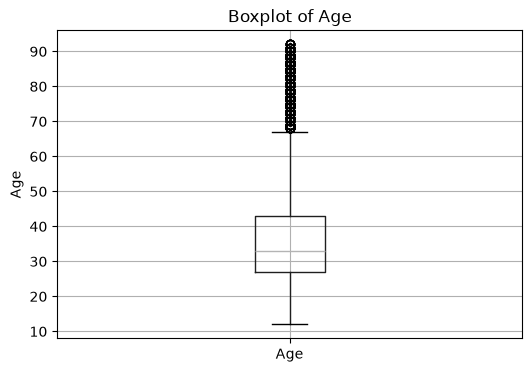

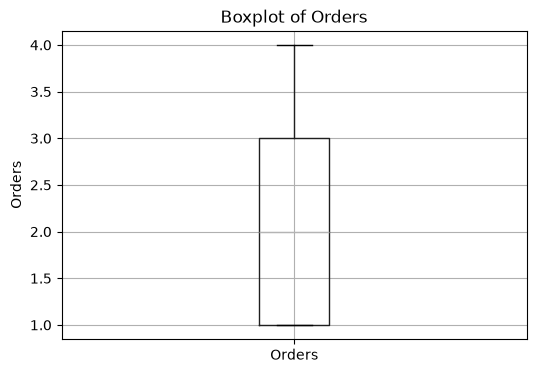

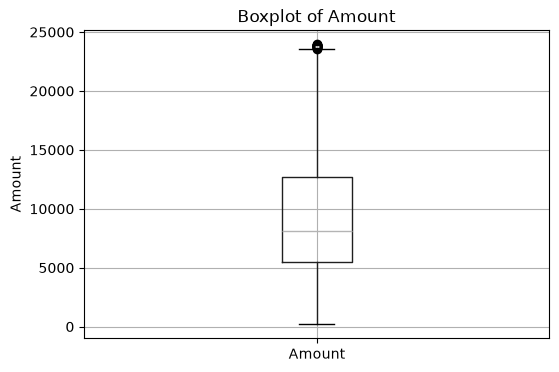

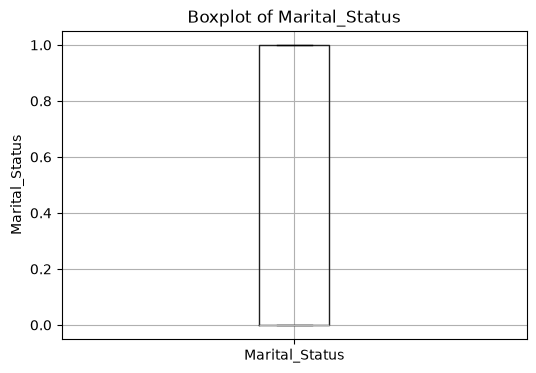

In [40]:
# plot boxplot

for col in num_cols:

  plt.figure(figsize=(6,4))

  df_copy.boxplot(column=[col])

  plt.title(f'Boxplot of {col}')
  plt.ylabel(col)
  plt.show()

**Interpretation:**

- `Age:` The age distribution is right-skewed, indicating a longer tail toward higher ages. The mode is 30, meaning that age 30 is the most frequently occurring individual age in the dataset. The mean age is higher than the median, which is consistent with the right-skewed distribution. Using the IQR method, the upper bound is 67, and ages above this value are identified as potential outliers. A total of 283 age observations were identified as upper outliers. The lower bound is 3, with no lower outliers identified.

- `Orders:` The distribution of Orders is approximately symmetric, with a skewness of 0.02, which is very close to zero. No potential outliers were identified using the IQR method. Since Orders is a discrete count variable ranging from 1 to 4, the number of orders per customer is concentrated within this limited range.

- `Amount:` The distribution of transaction amounts is positively skewed, with a skewness of 0.55. The mode is 7,907, meaning that 7,907 is the most frequently occurring transaction amount. Transaction amounts range from 188 to 23,952. Using the IQR method, the upper bound is 23,567.75, and 16 observations were identified above this threshold. These observations can therefore be considered potential unusually high transaction amounts.

- `Marital_Status:` Marital Status is a binary variable with values of 0 and 1. The mean of 0.42 indicates that approximately 42% of observations have a value of 1, while approximately 58% have a value of 0. The median and mode are both 0, indicating that 0 is the more frequently occurring marital-status category. The standard deviation of 0.49 reflects the variability expected from a binary variable, while the minimum and maximum values confirm that the variable contains only two categories, 0 and 1.


**Categorical Univariate Analysis**

- This section aims to understand the distribution and frequency of the dataset's categorical features. Each variable will be analyzed individually using frequency counts and appropriate visualizations to identify the most common categories, less represented groups, and notable patterns within the data.

For each categorical variable, the analysis will examine:

  - The number of unique categories.
  - The frequency and proportion of observations within each category.
  - The most and least represented categories.
  - Potentially imbalanced or highly concentrated categories.
  - Notable patterns that may help describe customer demographics, purchasing - behavior, and sales characteristics.

In [41]:
# how many observations belong to each category
cat_cols = (
    df_copy.select_dtypes(include='object')
    .drop(columns=['Cust_name', 'Product_ID'])
    .columns
    .tolist()
)

for col in cat_cols:

  print("=====" * 10)

  print(df_copy[col].value_counts(), '\n')
  print(f'Number of unique values in {col}: ', df_copy[col].nunique())

Gender
F    7838
M    3405
Name: count, dtype: int64 

Number of unique values in Gender:  2
Age Group
26-35    4538
36-45    2285
18-25    1878
46-50     987
51-55     831
55+       428
0-17      296
Name: count, dtype: int64 

Number of unique values in Age Group:  7
State
Uttar Pradesh       1944
Maharashtra         1523
Karnataka           1305
Delhi               1107
Madhya Pradesh       923
Andhra Pradesh       812
Himachal Pradesh     608
Kerala               453
Haryana              451
Bihar                433
Gujarat              428
Jharkhand            380
Uttarakhand          320
Rajasthan            231
Punjab               200
Telangana            125
Name: count, dtype: int64 

Number of unique values in State:  16
Zone
Central     4294
Southern    2695
Western     1951
Northern    1490
Eastern      813
Name: count, dtype: int64 

Number of unique values in Zone:  5
Occupation
IT Sector          1586
Healthcare         1408
Aviation           1309
Banking            11

In [42]:
# calculate percentages

for col in cat_cols:

  print("=====" * 10)

  print(df_copy[col].value_counts(normalize=True).mul(100).round(2))

Gender
F   69.71
M   30.29
Name: proportion, dtype: float64
Age Group
26-35   40.36
36-45   20.32
18-25   16.70
46-50    8.78
51-55    7.39
55+      3.81
0-17     2.63
Name: proportion, dtype: float64
State
Uttar Pradesh      17.29
Maharashtra        13.55
Karnataka          11.61
Delhi               9.85
Madhya Pradesh      8.21
Andhra Pradesh      7.22
Himachal Pradesh    5.41
Kerala              4.03
Haryana             4.01
Bihar               3.85
Gujarat             3.81
Jharkhand           3.38
Uttarakhand         2.85
Rajasthan           2.05
Punjab              1.78
Telangana           1.11
Name: proportion, dtype: float64
Zone
Central    38.19
Southern   23.97
Western    17.35
Northern   13.25
Eastern     7.23
Name: proportion, dtype: float64
Occupation
IT Sector         14.11
Healthcare        12.52
Aviation          11.64
Banking           10.13
Govt               7.60
Hospitality        6.24
Media              5.67
Automobile         5.03
Chemical           4.82
Lawyer    

**Interpretation:**

- `Gender:` The dataset is predominantly composed of female customers, with 69.71% of the observations, while male customers accounts for 30.29%. This indicates that there are substantially more female customers than male customers in the dataset.

- `Age Group:` This feature has 7 unique values, which are 0-17, 18-25, 26-35, 36-45, 46-50, 51-55, and 55 above. The age group that dominates the dataset are the customers ages 26-35, with a count of 4,538, followed by the 36-45 age group with a count of 2,285, followed by 18-25 year olds with a count of 1878, followed by 46-50 year olds with a count of 987, followed by 51-55 with a value of 831, then the 55 above age group with 428 customers, lastly the 0-17 age group with a count of 298. This indicates that most of the customers in this dataset are young adults in their late 20s to mid-30s.

- `State:` The dataset contains customers from 16 different states. Uttar Pradesh has the highest number of customers, with 1,944 observations (17.29%), followed by Maharashtra with 1,523 (13.55%) and Karnataka with 1,305 (11.61%). Delhi accounts for 1,107 customers (9.85%), while Madhya Pradesh has 923 (8.21%). The remaining states each account for less than 7% of the observations. This indicates that the customer base is concentrated in a relatively small number of states, with Uttar Pradesh, Maharashtra, and Karnataka contributing the largest shares of customers.

- `Zone:` The dataset contains 5 geographic zones. The Central zone has the largest customer population, with 4,294 observations (38.19%), followed by the Southern zone with 2,695 (23.97%), the Western zone with 1,951 (17.35%), the Northern zone with 1,490 (13.25%), and the Eastern zone with 813 (7.23%). This shows that the dataset is particularly concentrated in the Central zone, which contains more than one-third of all observations, while the Eastern zone has the smallest customer representation.

- `Occupation:` The dataset contains customers from 15 different occupational groups. IT Sector customers have the highest representation, with 1,586 observations (14.11%), followed by Healthcare with 1,408 (12.52%), Aviation with 1,309 (11.64%), and Banking with 1,139 (10.13%). Government employees account for 854 observations (7.60%), while the remaining occupations each represent less than 7% of the dataset. This indicates that the customer base is distributed across a diverse range of occupations, although IT, Healthcare, Aviation, and Banking customers make up relatively large portions of the dataset.

- `Product Category:` The dataset contains 18 different product categories. Clothing & Apparel is the most frequently observed category, with 2,653 observations (23.60%), followed by Food with 2,493 (22.17%) and Electronics & Gadgets with 2,082 (18.52%). Together, these three categories account for approximately 64.29% of all observations. Footwear & Shoes follows with 1,064 observations, while the remaining categories each account for less than 5% of the dataset. This indicates that customer purchases are heavily concentrated in Clothing & Apparel, Food, and Electronics & Gadgets, while categories such as Hand & Power Tools, Tupperware, Veterinary, and Decor have relatively few observations.


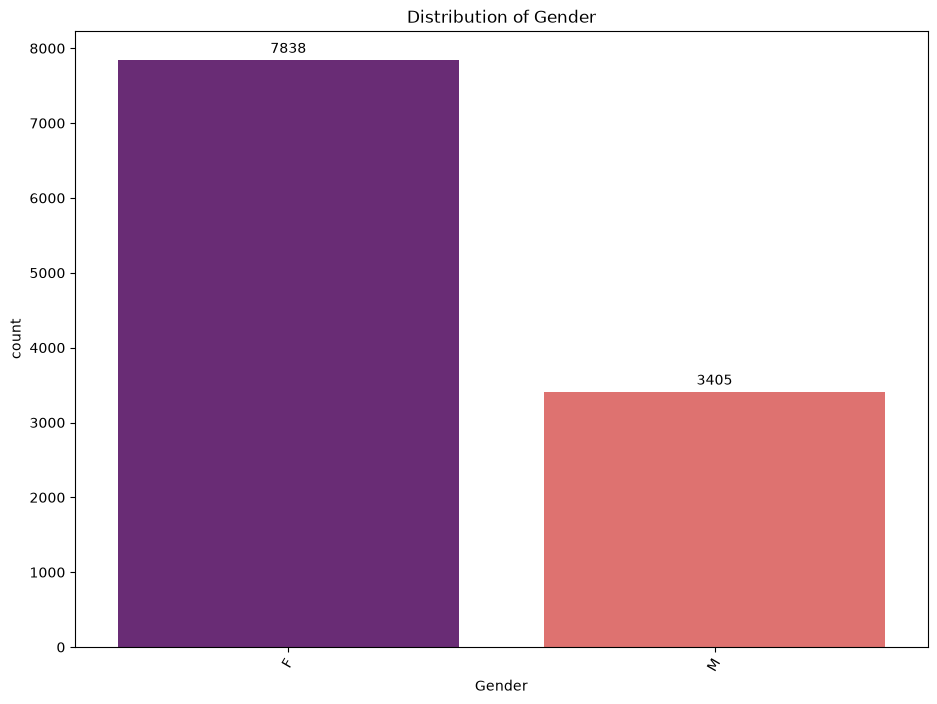

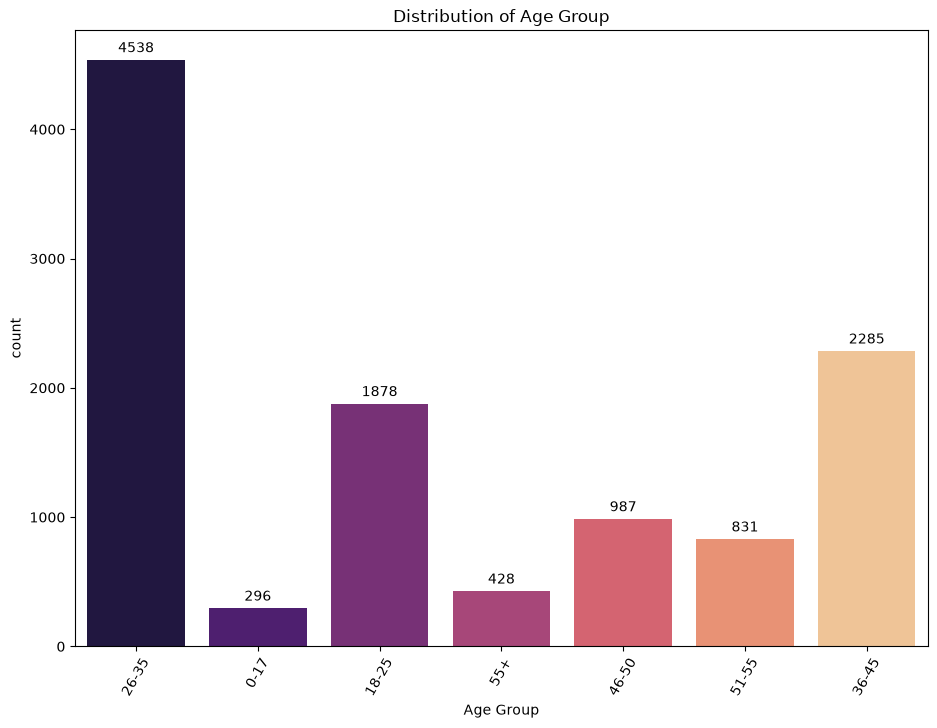

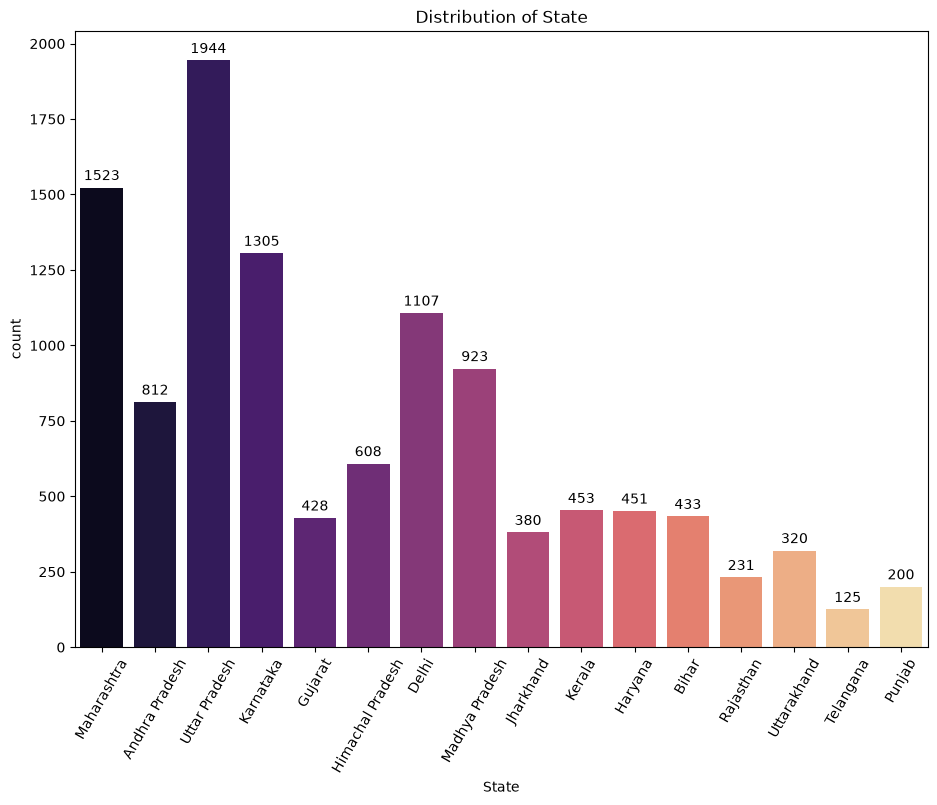

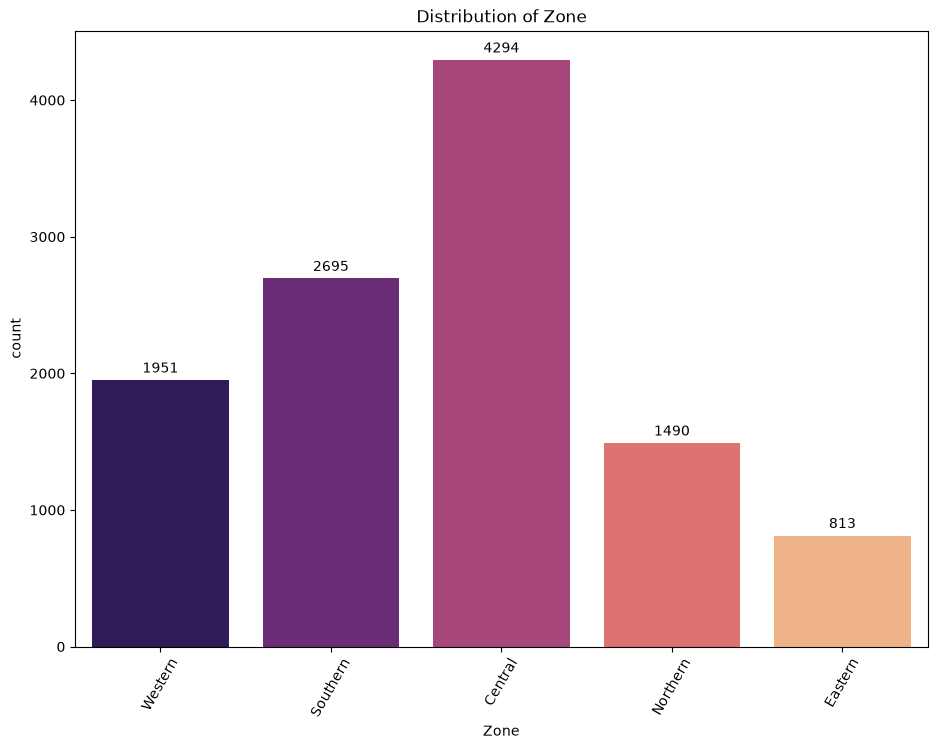

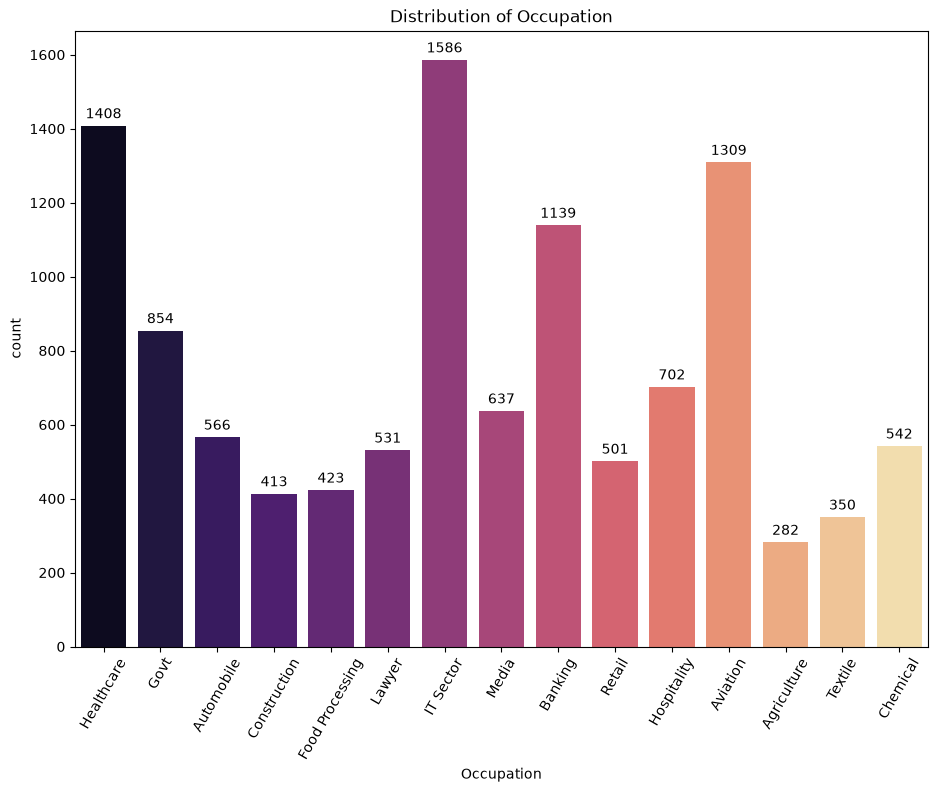

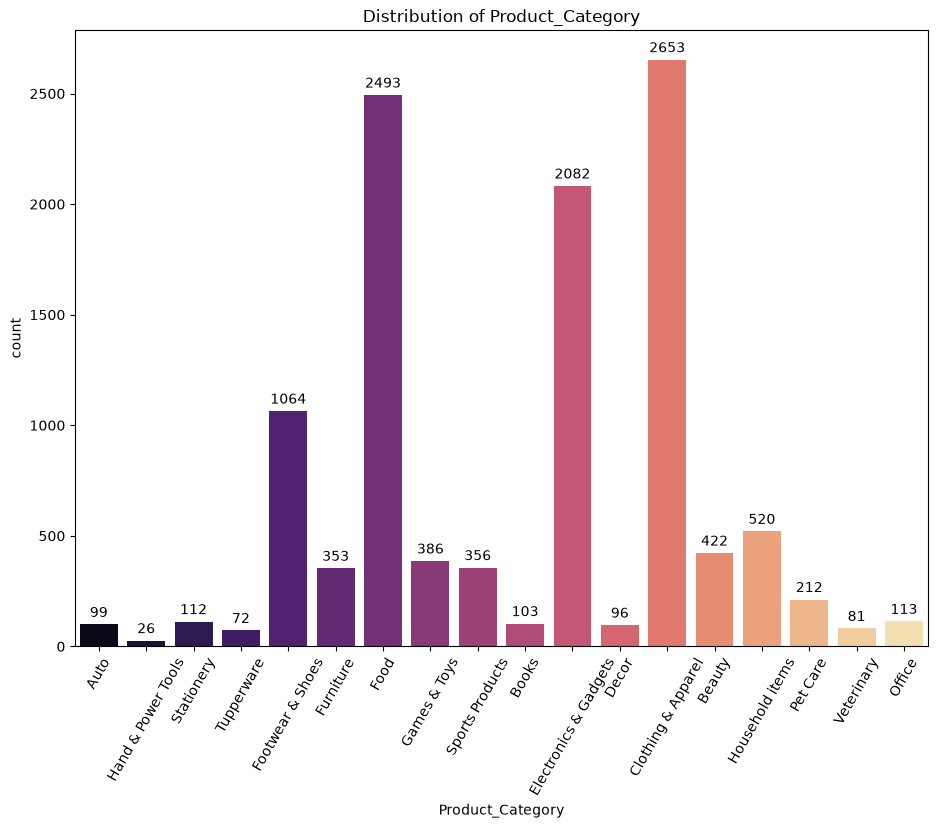

In [43]:
# plot count plots

for col in cat_cols:

  plt.figure(figsize=(11,8))

  ax = sns.countplot(
      data=df_copy,
      x=col,
      palette='magma'
  )

  for container in ax.containers:
    ax.bar_label(container, padding=3)

  plt.title(f'Distribution of {col}')
  plt.xticks(rotation=60)
  plt.show()

**Bivariate Analysis: Marital Status vs Numerical Columns**

Marital_Status
0    6518
1    4725
Name: count, dtype: int64
Marital_Status
0   57.97
1   42.03
Name: proportion, dtype: float64 



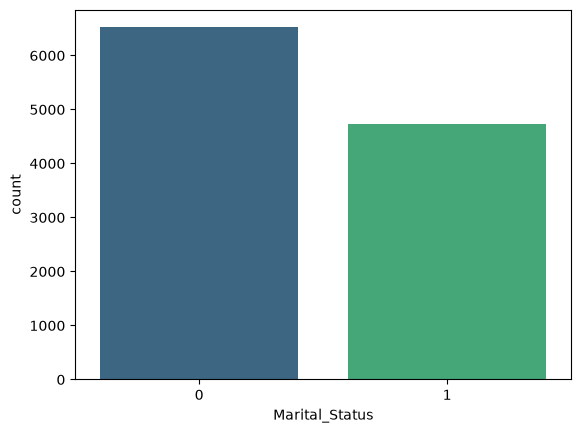

In [44]:
# inspect binary column
print(df_copy['Marital_Status'].value_counts())
print("=====" * 10)
print(df_copy['Marital_Status'].value_counts(normalize=True).mul(100), '\n')

sns.countplot(
    data=df_copy,
    x='Marital_Status',
    palette='viridis'
)

plt.show()

In [45]:
# Marital Status vs Numerical Columns
num_cols = [
    'Amount',
    'Orders',
    'Age'
]

for col in num_cols:
  num_by_marital = df_copy.groupby('Marital_Status')[col].agg(['sum', 'mean'])
  print(f'{col} by Marital Status: ')
  print(num_by_marital)
  print("=====" * 10)

  num_by_marital_pct = df_copy.groupby('Marital_Status')[col].sum().div(df_copy[col].sum()).mul(100).round(2)

  print(f'{col} percentage by Marital Status: ')
  print(num_by_marital_pct)
  print("=====" * 10, '\n')

Amount by Marital Status: 
                         sum     mean
Marital_Status                       
0              62,165,833.94 9,537.56
1              44,214,275.49 9,357.52
Amount percentage by Marital Status: 
Marital_Status
0   58.44
1   41.56
Name: Amount, dtype: float64

Orders by Marital Status: 
                  sum  mean
Marital_Status             
0               16243  2.49
1               11738  2.48
Orders percentage by Marital Status: 
Marital_Status
0   58.05
1   41.95
Name: Orders, dtype: float64

Age by Marital Status: 
                   sum  mean
Marital_Status              
0               231766 35.56
1               166493 35.24
Age percentage by Marital Status: 
Marital_Status
0   58.19
1   41.81
Name: Age, dtype: float64



**Interpretation:**

The dataset contains more unmarried customers than married customers, with **6,518 unmarried customers (57.97%)** and **4,725 married customers (42.03%)**.

The unmarried group accounts for **58.44% of total Amount**, while the married group accounts for **41.56%**. The average Amount is also slightly higher among unmarried customers at **9,537.56**, compared with **9,357.52** for married customers. This indicates that unmarried customers contribute a larger share of total spending and have a slightly higher average spending amount per record.

For Orders, unmarried customers account for **58.05% of total orders**, compared with **41.95%** for married customers. However, their average number of orders is nearly identical, at **2.49 for unmarried customers** and **2.48 for married customers**. This suggests that the higher total number of orders from unmarried customers is largely associated with their larger representation in the dataset rather than a meaningful difference in average order frequency.

For Age, the average ages are also very similar between the two groups. Unmarried customers have an average age of **35.56**, while married customers have an average age of **35.24**. This indicates that there is little difference in average age between the two marital-status groups.

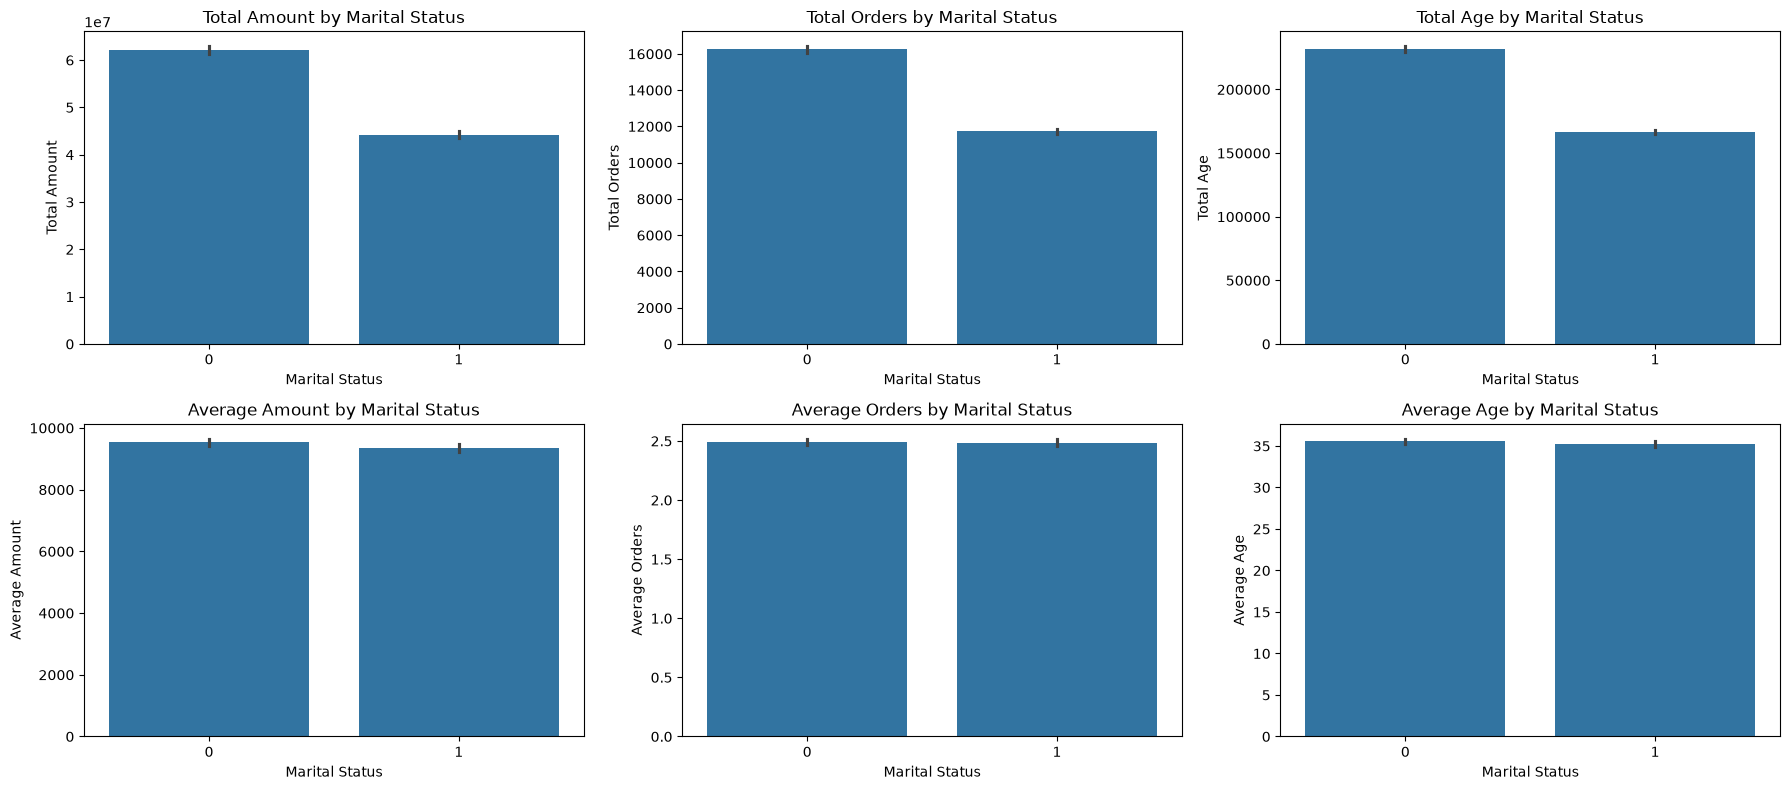

In [46]:
# plot num cols by marital status

num_cols= [
    'Amount',
    'Orders',
    'Age'
]

fig, axes = plt.subplots(
    2,3,
    figsize=(18,8)
)

for i, col in enumerate(num_cols):

  # total chart
  sns.barplot(
      data=df_copy,
      x='Marital_Status',
      y=col,
      estimator='sum',
      ax=axes[0, i]
  )

  axes[0, i].set_title(f'Total {col} by Marital Status')
  axes[0, i].set_xlabel('Marital Status')
  axes[0, i].set_ylabel(f'Total {col}')

  # average chart
  sns.barplot(
      data=df_copy,
      x='Marital_Status',
      y=col,
      estimator='mean',
      ax=axes[1, i]
  )

  axes[1, i].set_title(f'Average {col} by Marital Status')
  axes[1, i].set_xlabel('Marital Status')
  axes[1, i].set_ylabel(f'Average {col}')


plt.tight_layout()
plt.show()

**Bivariate Analysis: Marital Status vs. Categorical Columns**

In [47]:
for col in cat_cols:

    # Count
    marital_cat = df_copy[['Marital_Status', col]].value_counts()

    # Percentage within each marital status
    marital_cat_pct = pd.crosstab(
        df_copy['Marital_Status'],
        df_copy[col],
        normalize='index'
    ).mul(100).round(2)

    print(f'{col} by Marital Status:')
    print(marital_cat)
    print()

    print(f'{col} percentage by Marital Status:')
    print(marital_cat_pct)
    print('=' * 50)

Gender by Marital Status:
Marital_Status  Gender
0               F         4575
1               F         3263
0               M         1943
1               M         1462
Name: count, dtype: int64

Gender percentage by Marital Status:
Gender             F     M
Marital_Status            
0              70.19 29.81
1              69.06 30.94
Age Group by Marital Status:
Marital_Status  Age Group
0               26-35        2608
1               26-35        1930
0               36-45        1318
                18-25        1077
1               36-45         967
                18-25         801
0               46-50         577
                51-55         495
1               46-50         410
                51-55         336
0               55+           259
                0-17          184
1               55+           169
                0-17          112
Name: count, dtype: int64

Age Group percentage by Marital Status:
Age Group       0-17  18-25  26-35  36-45  46-50  51-55  

**Interpretation:**

- Both unmarried and married customers are predominantly female, with females accounting for 70.19% of unmarried customers and 69.06% of married customers. The similar proportions indicate little difference in gender composition between the two marital-status groups.

- The 26–35 age group is the largest segment for both unmarried and married customers, accounting for 40.01% and 40.85%, respectively. The distributions across the remaining age groups are also similar, suggesting that marital status does not substantially differentiate the age-group composition of the dataset.

- Uttar Pradesh has the largest share of customers in both marital-status groups, accounting for 17.18% of unmarried customers and 17.44% of married customers. Maharashtra, Karnataka, Delhi, and Madhya Pradesh also represent relatively large portions of both groups. Overall, the state distributions are highly similar, indicating limited differentiation between married and unmarried customers based on geographic location.

- The Central zone represents the largest share of both unmarried and married customers, accounting for 38.05% and 38.39%, respectively. The Southern zone is the second-largest for both groups. The relatively small differences across zones indicate that the geographic distribution is broadly similar regardless of marital status.

- The occupational composition shows greater differences between marital-status groups compared with gender, age group, state, and zone. Healthcare accounts for 15.56% of unmarried customers but only 8.34% of married customers. In contrast, IT Sector and Banking represent larger shares among married customers, at 15.22% and 12.04%, respectively. This suggests that occupation may provide more differentiation between marital-status groups and could be worth investigating further for customer segmentation.

- Clothing & Apparel is the largest product category for both unmarried and married customers, accounting for 23.52% and 23.70%, respectively. Food represents a larger share among unmarried customers (23.03%), while Electronics & Gadgets represents a larger share among married customers (19.26%). Overall, however, the product-category distributions are relatively similar between the two groups.

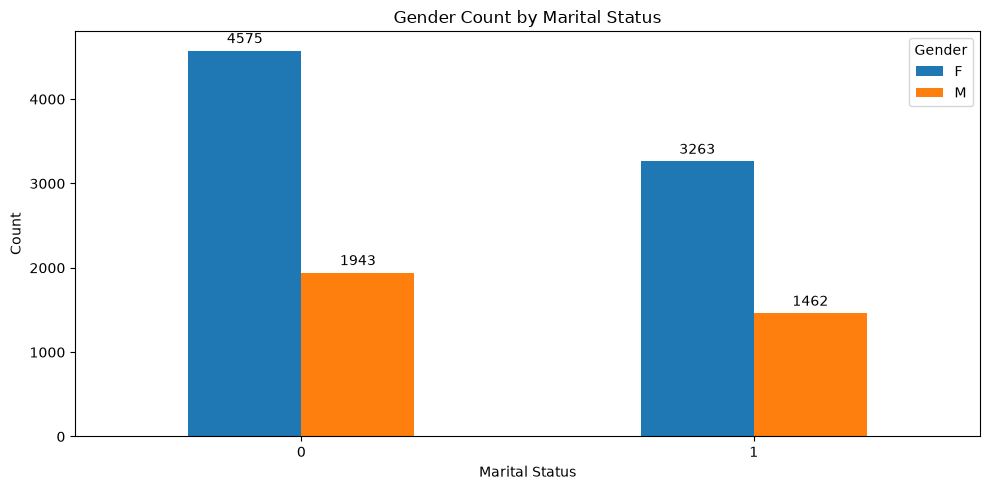

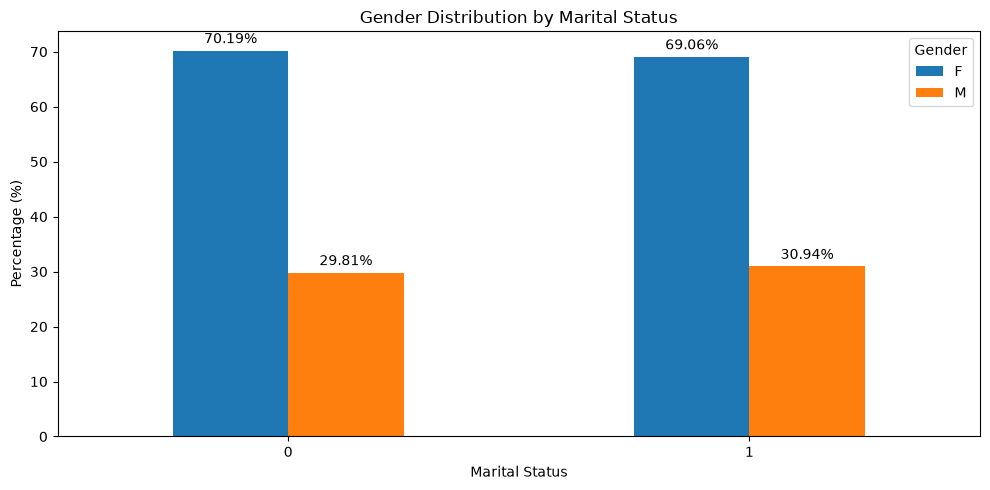

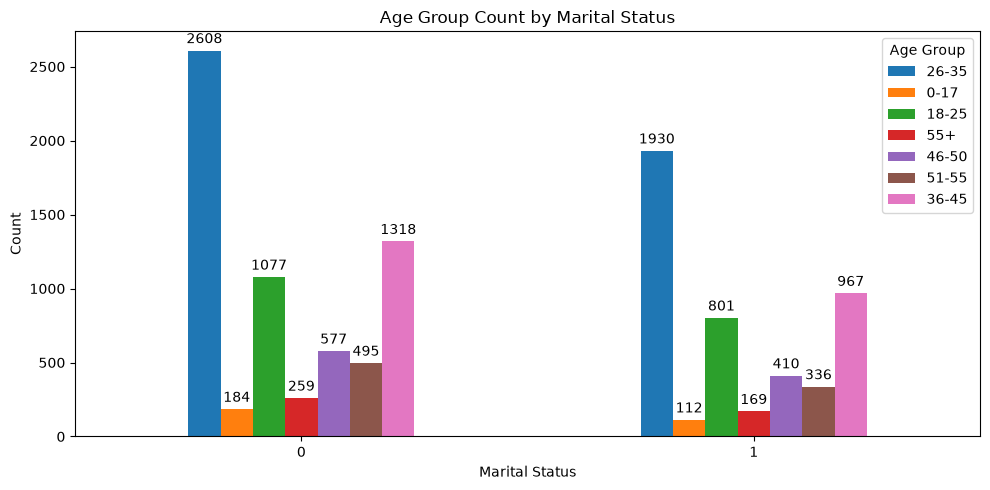

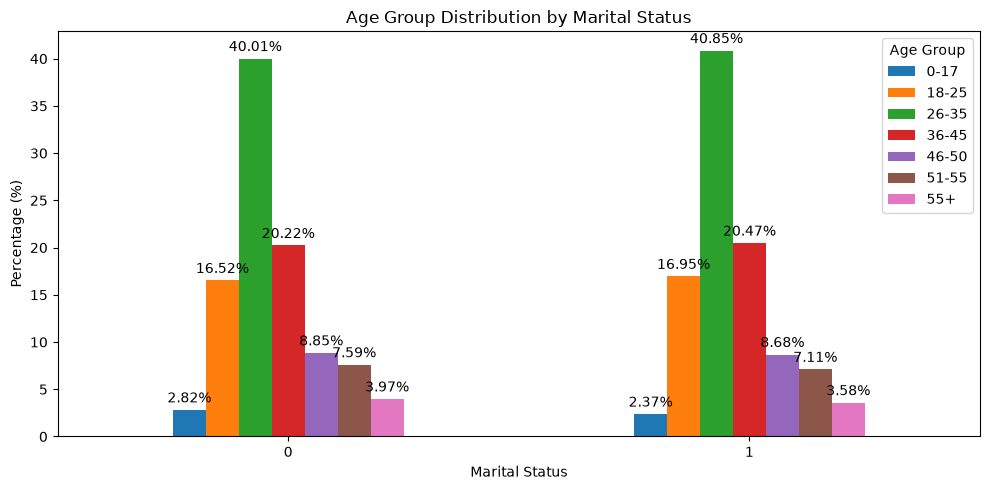

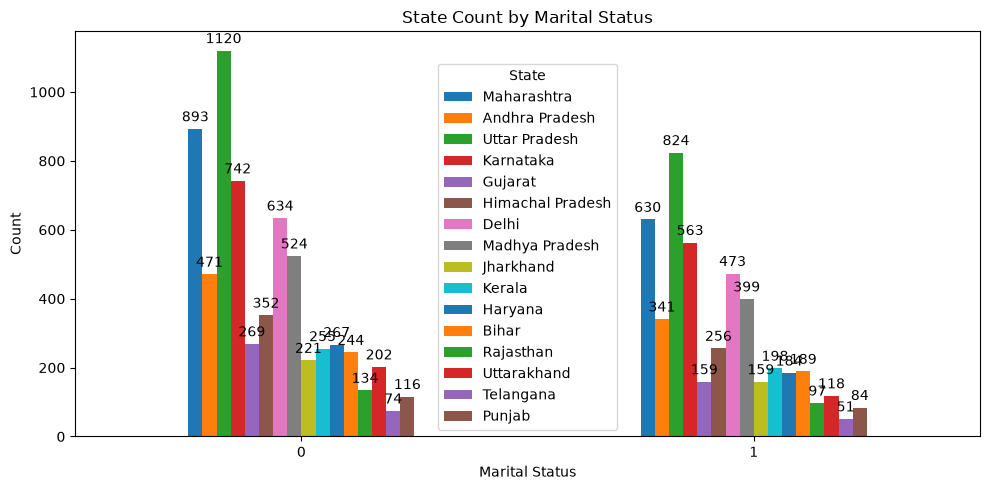

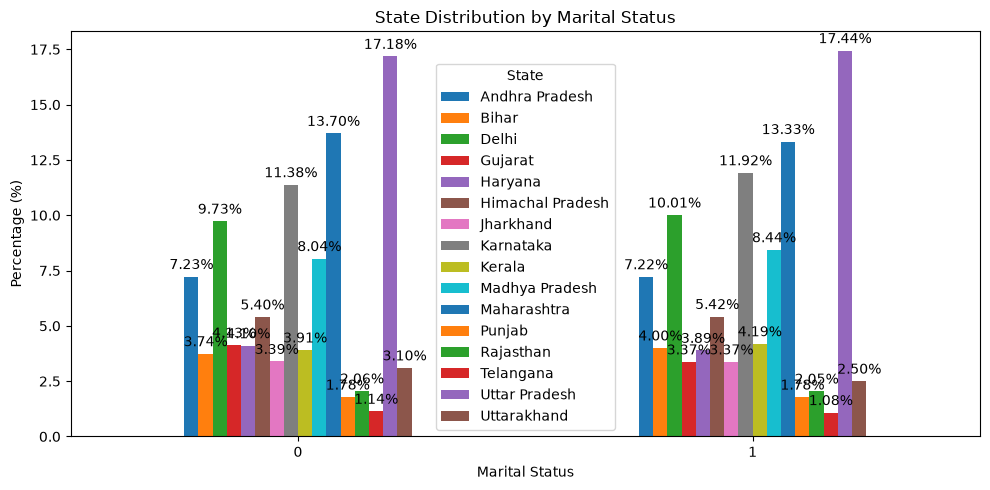

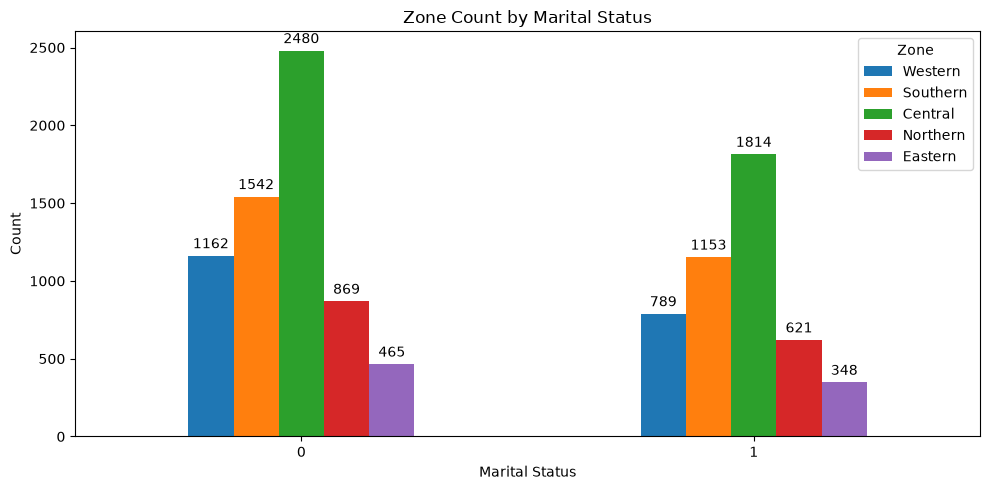

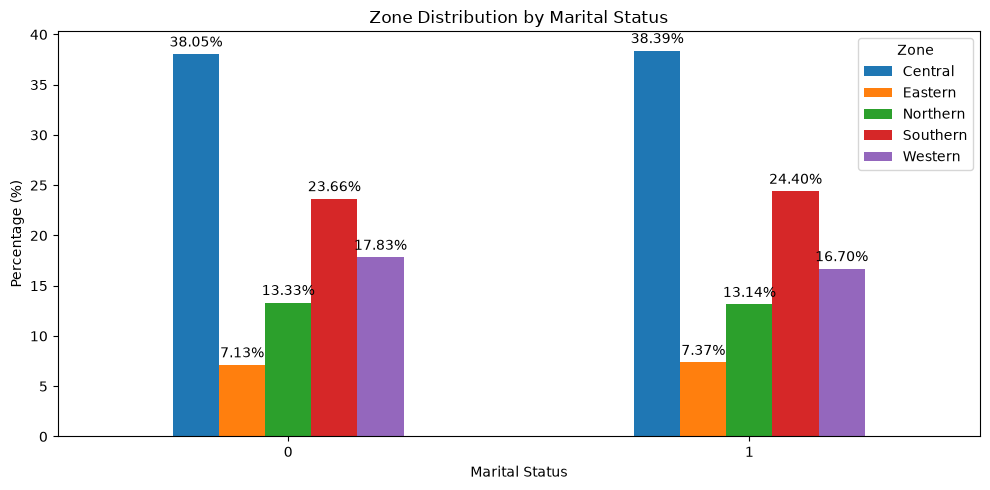

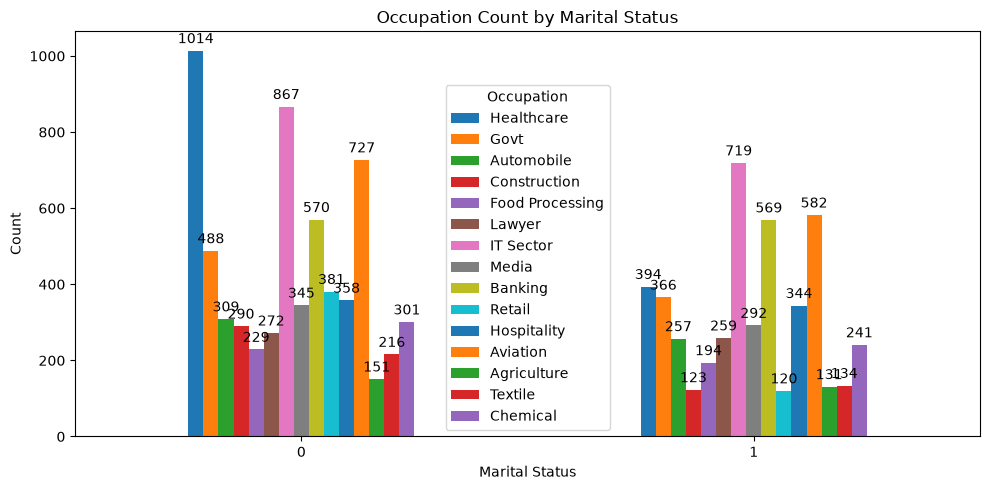

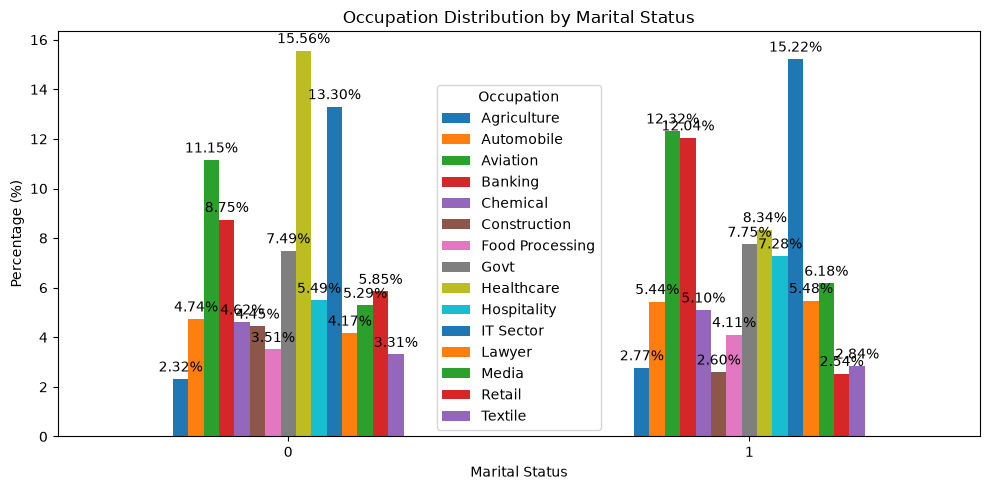

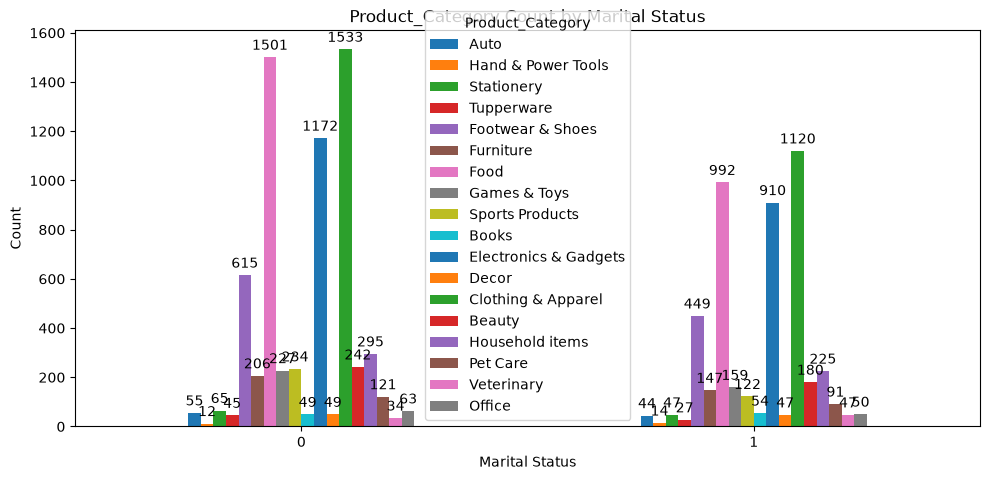

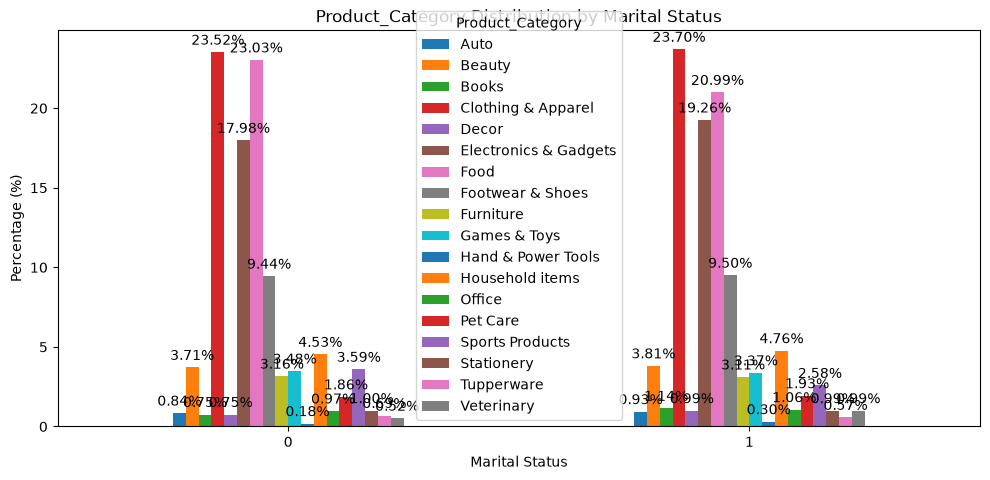

In [48]:
for col in cat_cols:

    # Count
    marital_cat = df_copy[['Marital_Status', col]].value_counts()

    # Percentage within each marital status
    marital_cat_pct = pd.crosstab(
        df_copy['Marital_Status'],
        df_copy[col],
        normalize='index'
    ).mul(100).round(2)

    # Count plot
    ax = marital_cat.unstack().plot(
        kind='bar',
        figsize=(10, 5)
    )

    plt.title(f'{col} Count by Marital Status')
    plt.xlabel('Marital Status')
    plt.ylabel('Count')
    plt.legend(title=col)
    plt.xticks(rotation=0)

    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.tight_layout()
    plt.show()


    # Percentage plot
    ax = marital_cat_pct.plot(
        kind='bar',
        figsize=(10, 5)
    )

    plt.title(f'{col} Distribution by Marital Status')
    plt.xlabel('Marital Status')
    plt.ylabel('Percentage (%)')
    plt.legend(title=col)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.2f%%',
            padding=3
        )

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

**Bivariate Analysis: Gender vs Numerical Columns**

In [49]:
# Gender vs Numerical Columns
num_cols = [
    'Amount',
    'Orders',
    'Age'
]

for col in num_cols:
    num_by_gender = df_copy.groupby('Gender')[col].agg(['sum', 'mean'])
    
    print(f'{col} by Gender:')
    print(num_by_gender)
    print("=====" * 10)

    num_by_gender_pct = (
        df_copy.groupby('Gender')[col]
        .sum()
        .div(df_copy[col].sum())
        .mul(100)
        .round(2)
    )

    print(f'{col} percentage by Gender:')
    print(num_by_gender_pct)
    print("=====" * 10, '\n')

Amount by Gender:
                 sum     mean
Gender                       
F      74,473,386.93 9,501.58
M      31,906,722.50 9,370.55
Amount percentage by Gender:
Gender
F   70.01
M   29.99
Name: Amount, dtype: float64

Orders by Gender:
          sum  mean
Gender             
F       19554  2.49
M        8427  2.47
Orders percentage by Gender:
Gender
F   69.88
M   30.12
Name: Orders, dtype: float64

Age by Gender:
           sum  mean
Gender              
F       276985 35.34
M       121274 35.62
Age percentage by Gender:
Gender
F   69.55
M   30.45
Name: Age, dtype: float64



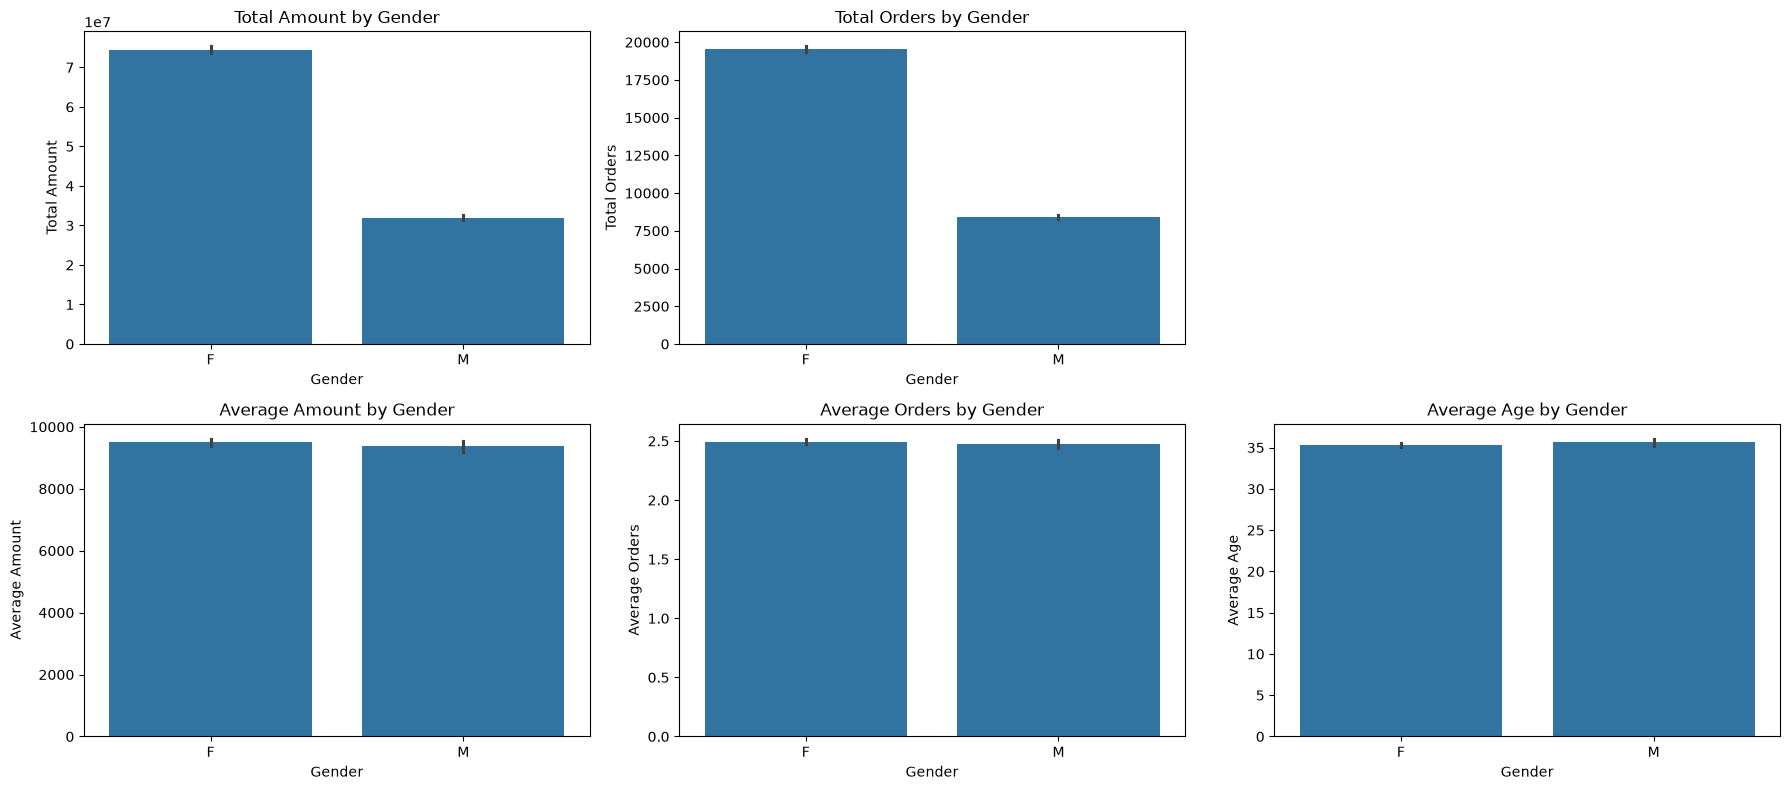

In [50]:
# Plot numerical columns by Gender

sum_cols = [
    'Amount',
    'Orders'
]

mean_cols = [
    'Amount',
    'Orders',
    'Age'
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 8)
)

# Total charts
for i, col in enumerate(sum_cols):

    sns.barplot(
        data=df_copy,
        x='Gender',
        y=col,
        estimator='sum',
        ax=axes[0, i]
    )

    axes[0, i].set_title(f'Total {col} by Gender')
    axes[0, i].set_xlabel('Gender')
    axes[0, i].set_ylabel(f'Total {col}')


# Average charts
for i, col in enumerate(mean_cols):

    sns.barplot(
        data=df_copy,
        x='Gender',
        y=col,
        estimator='mean',
        ax=axes[1, i]
    )

    axes[1, i].set_title(f'Average {col} by Gender')
    axes[1, i].set_xlabel('Gender')
    axes[1, i].set_ylabel(f'Average {col}')


# Remove the unused top-right subplot
fig.delaxes(axes[0, 2])

plt.tight_layout()
plt.show()

**Bivariate Analysis: Gender vs Categorical Columns**

In [51]:
cat_cols_no_gender = [
    'Age Group',
    'Occupation',
    'State',
    'Zone',
    'Product_Category'
]

for col in cat_cols_no_gender:

    # Count
    gender_cat = df_copy[['Gender', col]].value_counts()

    # Percentage within each gender
    gender_cat_pct = pd.crosstab(
        df_copy['Gender'],
        df_copy[col],
        normalize='index'
    ).mul(100).round(2)

    print(f'{col} by Gender:')
    print(gender_cat)
    print()

    print(f'{col} percentage by Gender:')
    print(gender_cat_pct)
    print('=' * 50)

Age Group by Gender:
Gender  Age Group
F       26-35        3268
        36-45        1580
        18-25        1305
M       26-35        1270
        36-45         705
F       46-50         696
M       18-25         573
F       51-55         554
M       46-50         291
        51-55         277
F       55+           273
        0-17          162
M       55+           155
        0-17          134
Name: count, dtype: int64

Age Group percentage by Gender:
Age Group  0-17  18-25  26-35  36-45  46-50  51-55  55+
Gender                                                 
F          2.07  16.65  41.69  20.16   8.88   7.07 3.48
M          3.94  16.83  37.30  20.70   8.55   8.14 4.55
Occupation by Gender:
Gender  Occupation     
F       IT Sector          1075
        Healthcare          968
        Aviation            931
        Banking             825
        Govt                605
M       IT Sector           511
F       Hospitality         468
M       Healthcare          440
F       Medi

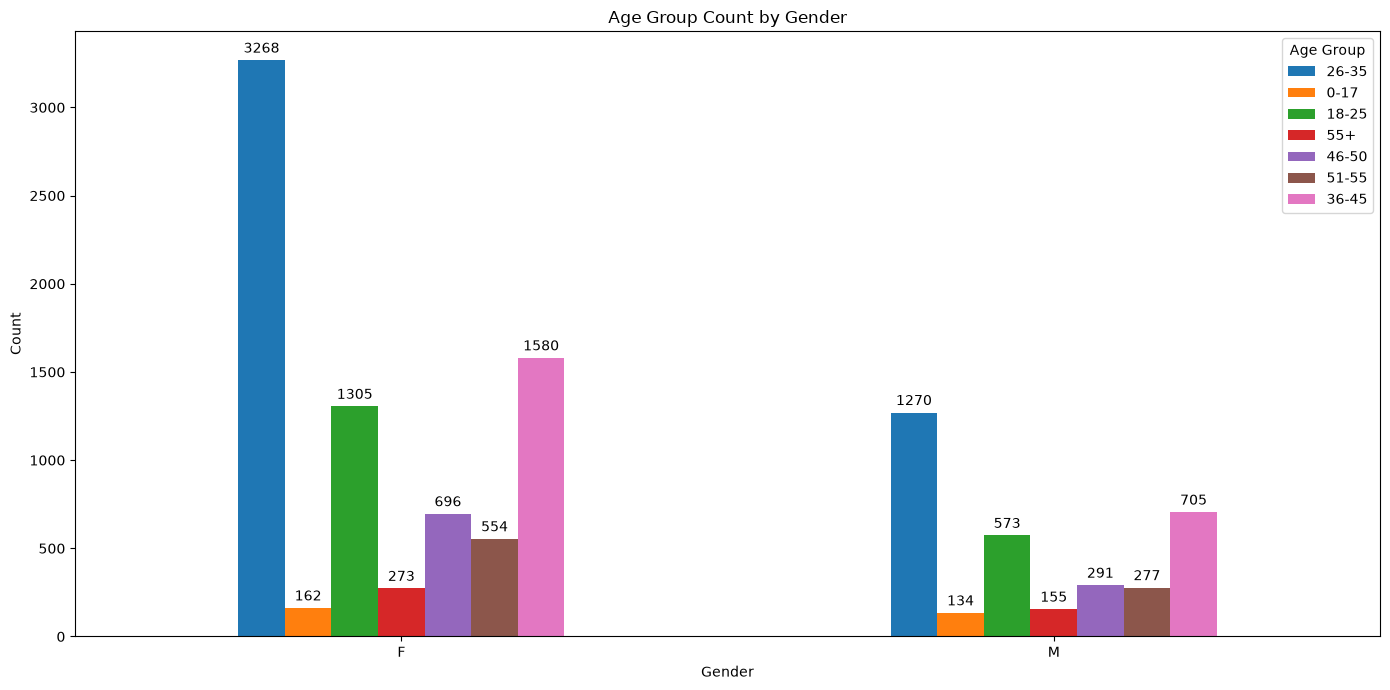

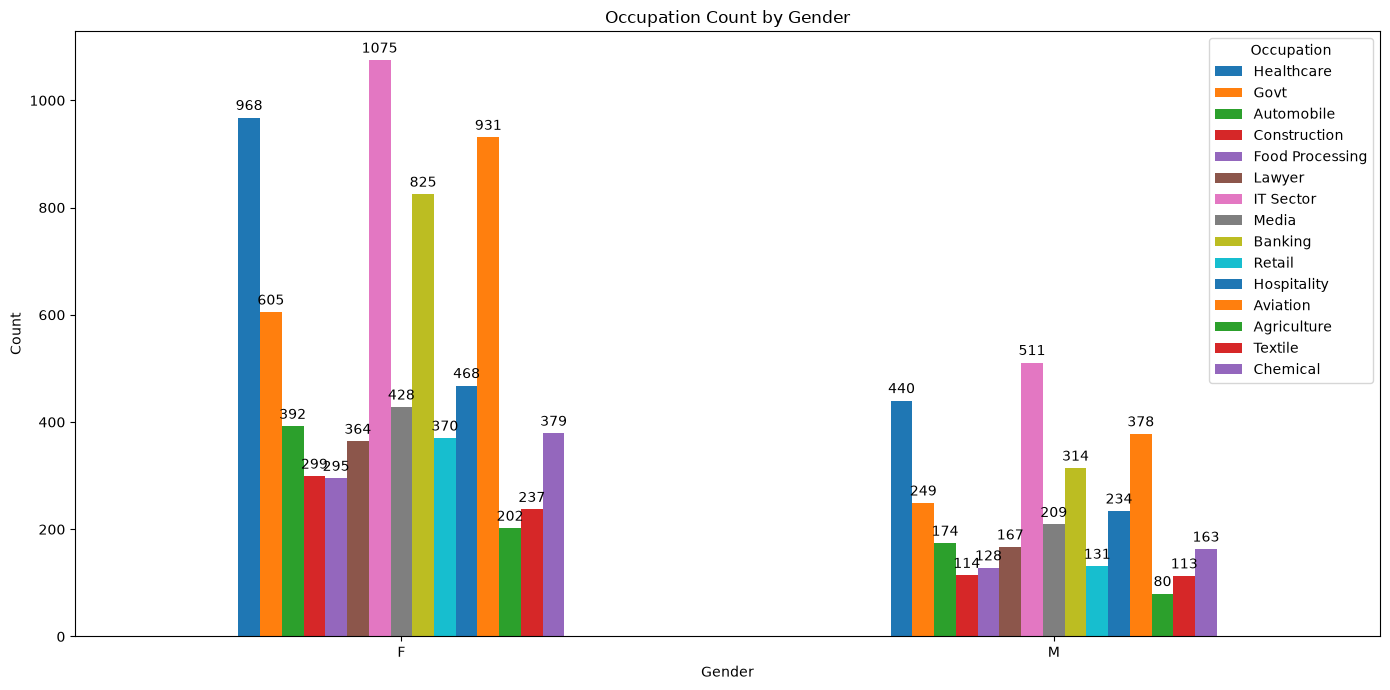

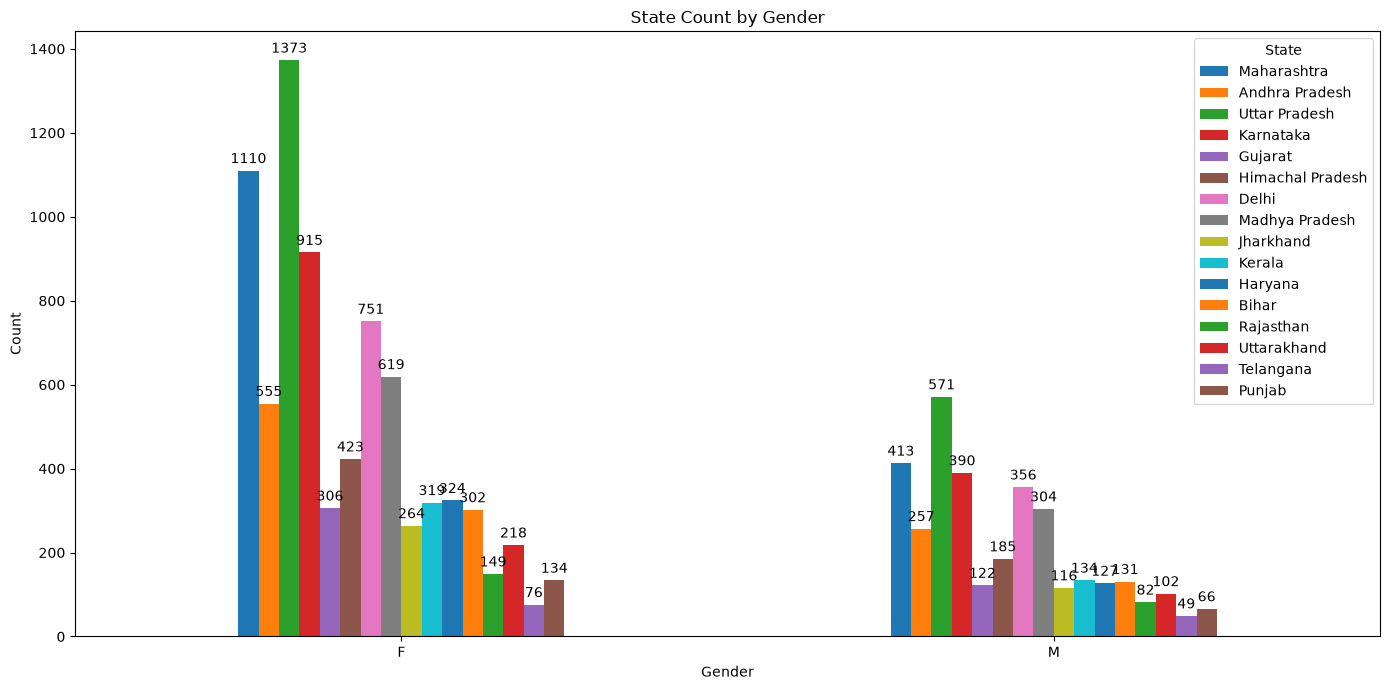

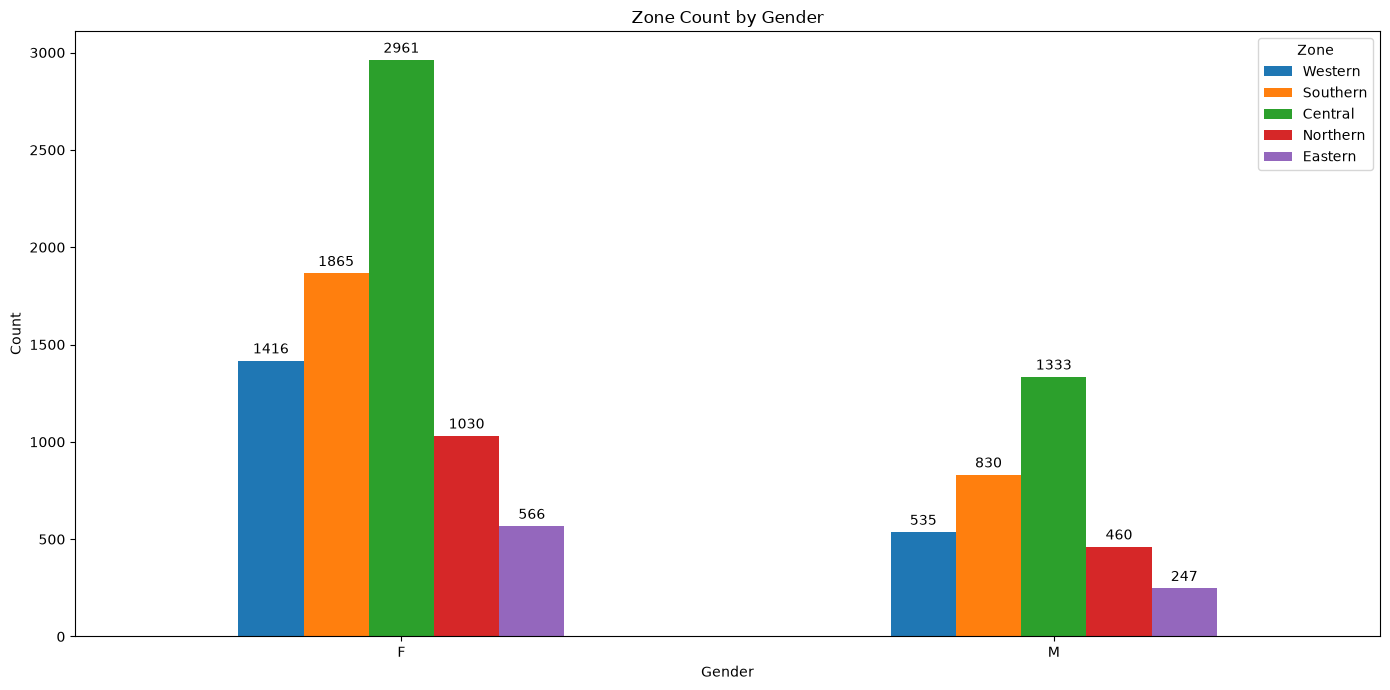

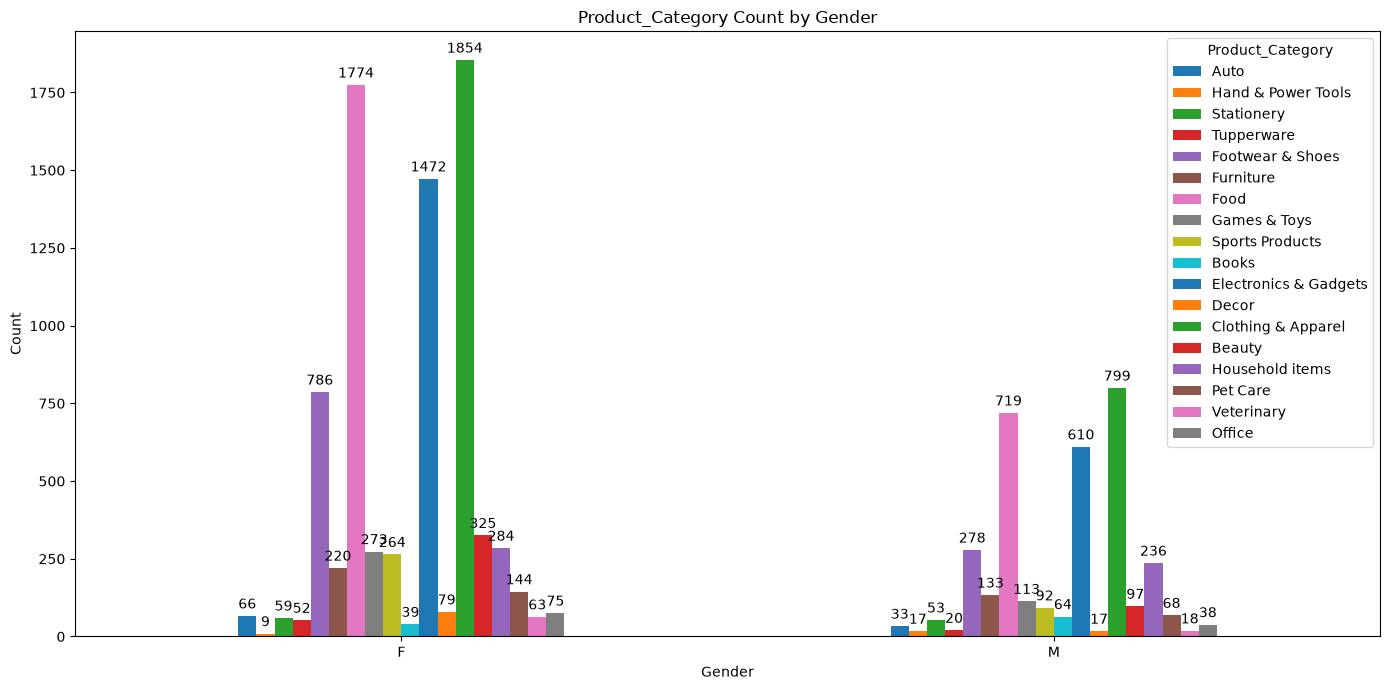

In [52]:
for col in cat_cols_no_gender:

    # Count
    gender_cat = df_copy[['Gender', col]].value_counts()

    # Percentage within each marital status
    gender_cat_pct = pd.crosstab(
        df_copy['Gender'],
        df_copy[col],
        normalize='index'
    ).mul(100).round(2)

    # Count plot
    ax = gender_cat.unstack().plot(
        kind='bar',
        figsize=(14, 7)
    )

    plt.title(f'{col} Count by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.legend(title=col)
    plt.xticks(rotation=0)

    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.tight_layout()
    plt.show()

**Bivariate Analysis: Age Group vs Numerical Columns**

In [53]:
for col in num_cols:
    num_by_age_group = df_copy.groupby('Age Group')[col].agg(['sum', 'mean'])

    print(f'{col} by Age Group:')
    print(num_by_age_group)
    print("=====" * 10)

    num_by_age_group_pct = (
        df_copy.groupby('Age Group')[col]
        .sum()
        .div(df_copy[col].sum())
        .mul(100)
        .round(2)
    )

    print(f'{col} percentage by Age Group:')
    print(num_by_age_group_pct)
    print("=====" * 10, '\n')

Amount by Age Group:
                    sum     mean
Age Group                       
0-17       2,699,653.00 9,120.45
18-25     17,235,530.00 9,177.60
26-35     42,613,278.44 9,390.32
36-45     22,181,889.49 9,707.61
46-50      9,278,997.00 9,401.21
51-55      8,270,487.00 9,952.45
55+        4,100,274.50 9,580.08
Amount percentage by Age Group:
Age Group
0-17     2.54
18-25   16.20
26-35   40.06
36-45   20.85
46-50    8.72
51-55    7.77
55+      3.85
Name: Amount, dtype: float64

Orders by Age Group:
             sum  mean
Age Group             
0-17         690  2.33
18-25       4646  2.47
26-35      11381  2.51
36-45       5693  2.49
46-50       2379  2.41
51-55       2115  2.55
55+         1077  2.52
Orders percentage by Age Group:
Age Group
0-17     2.47
18-25   16.60
26-35   40.67
36-45   20.35
46-50    8.50
51-55    7.56
55+      3.85
Name: Orders, dtype: float64

Age by Age Group:
              sum  mean
Age Group              
0-17         4302 14.53
18-25       40360 21.49


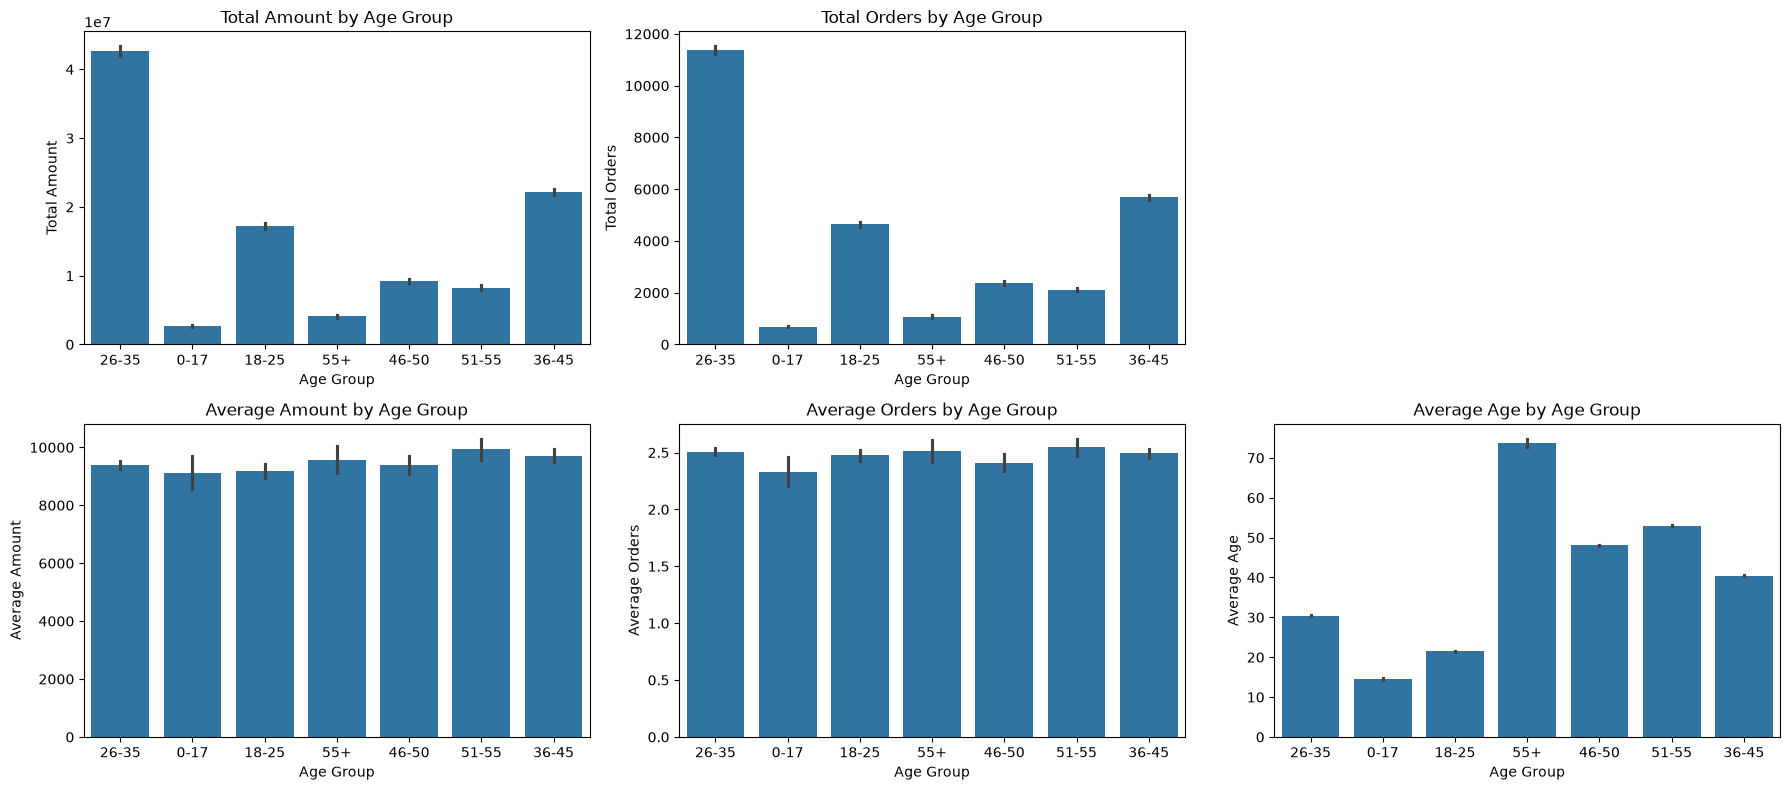

In [54]:
# Plot numerical columns by Age Group

sum_cols = [
    'Amount',
    'Orders'
]

mean_cols = [
    'Amount',
    'Orders',
    'Age'
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 8)
)

# Total charts
for i, col in enumerate(sum_cols):

    sns.barplot(
        data=df_copy,
        x='Age Group',
        y=col,
        estimator='sum',
        ax=axes[0, i]
    )

    axes[0, i].set_title(f'Total {col} by Age Group')
    axes[0, i].set_xlabel('Age Group')
    axes[0, i].set_ylabel(f'Total {col}')


# Average charts
for i, col in enumerate(mean_cols):

    sns.barplot(
        data=df_copy,
        x='Age Group',
        y=col,
        estimator='mean',
        ax=axes[1, i]
    )

    axes[1, i].set_title(f'Average {col} by Age Group')
    axes[1, i].set_xlabel('Age Group')
    axes[1, i].set_ylabel(f'Average {col}')


# Remove the unused top-right subplot
fig.delaxes(axes[0, 2])

plt.tight_layout()
plt.show()

**Bivariate Analysis: Age Group vs Categorical Columns**

In [55]:
cat_cols_no_age_group = [
    'Occupation',
    'State',
    'Zone',
    'Product_Category'
]

for col in cat_cols_no_age_group:

    # Count
    age_group_cat = df_copy[['Age Group', col]].value_counts()

    # Percentage within each gender
    age_group_cat_pct = pd.crosstab(
        df_copy['Age Group'],
        df_copy[col],
        normalize='index'
    ).mul(100).round(2)

    print(f'{col} by Age Group:')
    print(age_group_cat)
    print()

    print(f'{col} percentage by Age Group:')
    print(age_group_cat_pct)
    print('=' * 50)

Occupation by Age Group:
Age Group  Occupation     
26-35      IT Sector          658
           Healthcare         571
           Aviation           551
           Banking            477
           Govt               319
36-45      IT Sector          315
           Healthcare         273
26-35      Hospitality        267
36-45      Aviation           263
26-35      Media              253
18-25      IT Sector          247
           Healthcare         225
36-45      Banking            224
26-35      Automobile         222
           Lawyer             220
           Retail             219
18-25      Aviation           216
26-35      Chemical           216
18-25      Banking            194
36-45      Govt               177
26-35      Construction       176
18-25      Govt               161
26-35      Food Processing    152
46-50      IT Sector          142
36-45      Chemical           139
26-35      Textile            136
36-45      Hospitality        135
46-50      Healthcare         

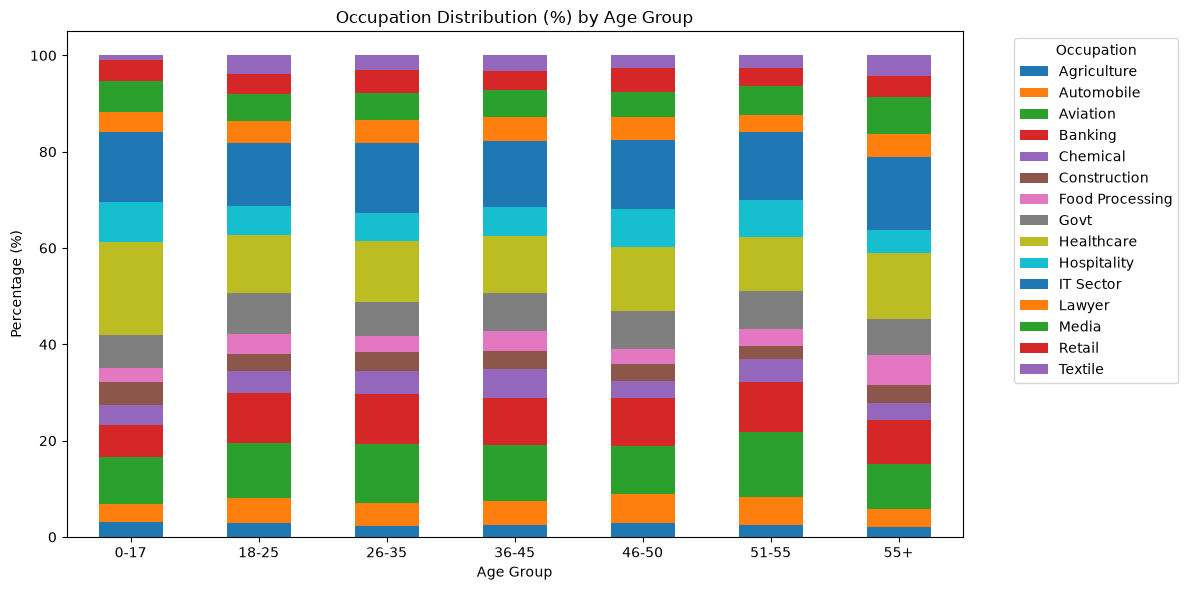

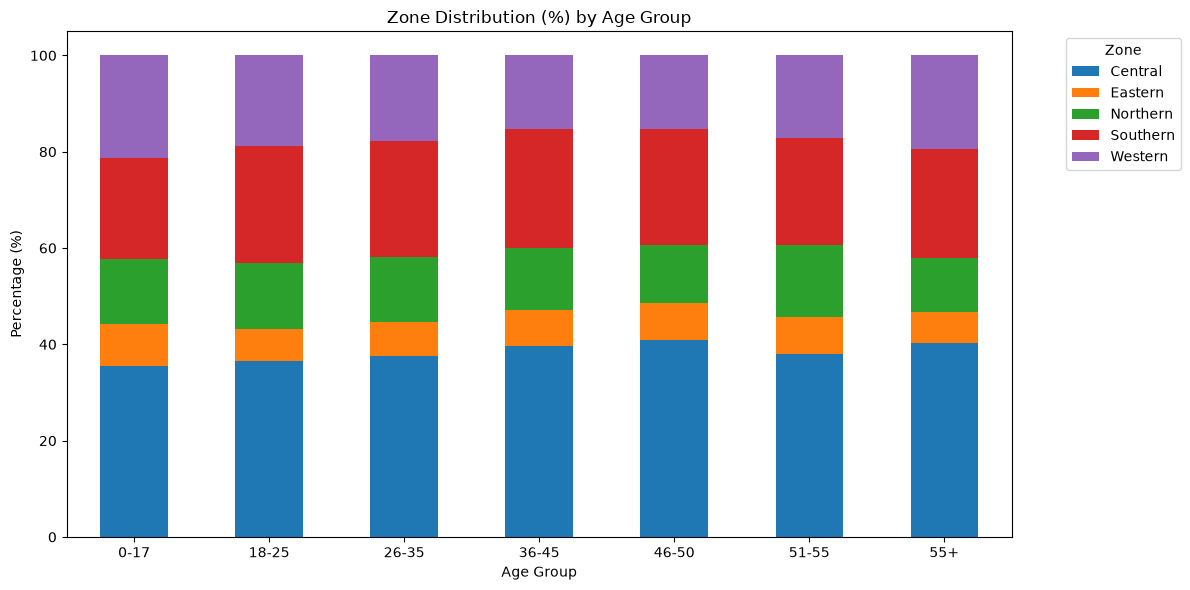

In [63]:
cat_cols_age_group_bar = [
    'Occupation',
    'Zone'
]

for col in cat_cols_age_group_bar:

    age_group_cat_pct = pd.crosstab(
        df_copy['Age Group'],
        df_copy[col],
        normalize='index'
    ).mul(100)

    ax = age_group_cat_pct.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6)
    )

    plt.title(f'{col} Distribution (%) by Age Group')
    plt.xlabel('Age Group')
    plt.ylabel('Percentage (%)')

    plt.legend(
        title=col,
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

State      Andhra Pradesh  Bihar  Delhi  Gujarat  Haryana  Himachal Pradesh  \
Age Group                                                                     
0-17                 5.74   4.39   6.08     4.73     3.38              5.74   
18-25                7.56   3.78   7.99     3.73     4.53              5.11   
26-35                7.03   3.79  10.40     3.61     3.99              5.46   
36-45                7.48   3.72  11.55     3.72     3.41              5.56   
46-50                6.59   4.05  10.74     3.44     4.66              4.36   
51-55                7.70   4.21   8.42     4.81     4.45              6.14   
55+                  7.94   3.97   6.31     4.91     3.27              6.07   

State      Jharkhand  Karnataka  Kerala  Madhya Pradesh  Maharashtra  Punjab  \
Age Group                                                                      
0-17            4.39       8.11    6.42           10.14        16.55    2.03   
18-25           2.98      10.92    4.90         

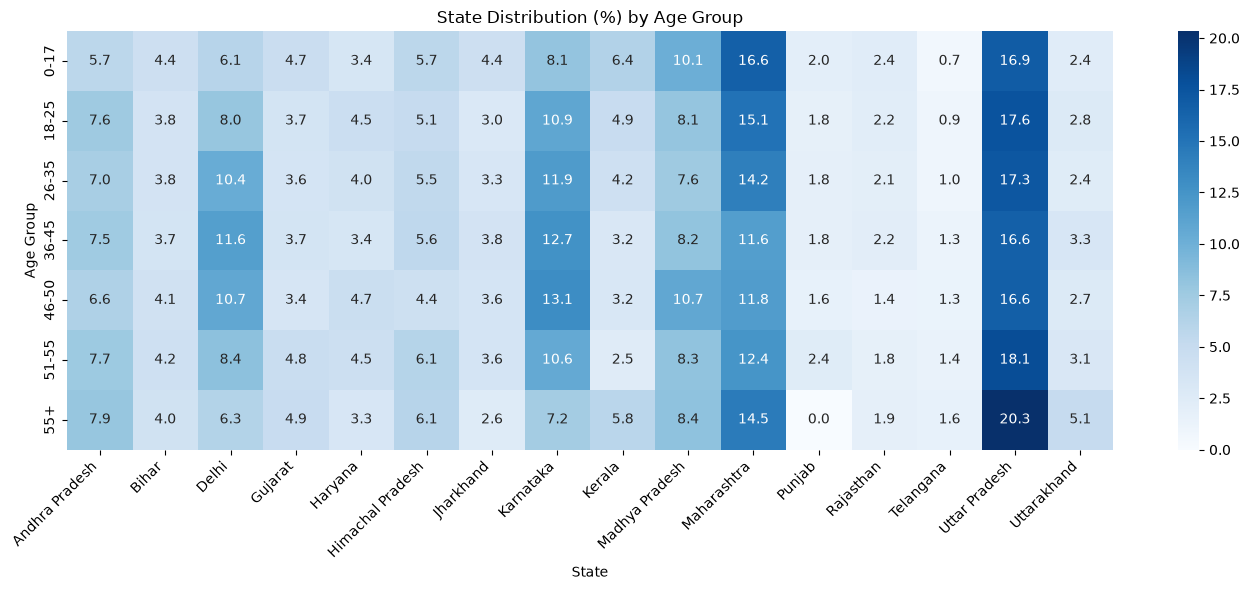

In [60]:
# percentage of customers within each age group who come from each state
state_age_group_pct = pd.crosstab(
    df_copy['Age Group'],
    df_copy['State'],
    normalize='index'
).mul(100)

print(state_age_group_pct, '\n')

plt.figure(figsize=(14, 6))

sns.heatmap(
    state_age_group_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('State Distribution (%) by Age Group')
plt.xlabel('State')
plt.ylabel('Age Group')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Product_Category  Auto  Beauty  Books  Clothing & Apparel  Decor  \
Age Group                                                          
0-17              1.01    3.04   0.34               24.32   0.34   
18-25             0.91    4.10   1.06               24.92   1.01   
26-35             0.95    3.61   0.90               23.27   0.73   
36-45             0.79    3.59   0.96               23.28   1.01   
46-50             0.61    3.34   0.91               23.71   1.01   
51-55             0.84    4.45   0.84               22.62   0.60   
55+               1.17    4.67   0.70               24.07   1.17   

Product_Category  Electronics & Gadgets  Food  Footwear & Shoes  Furniture  \
Age Group                                                                    
0-17                              20.61 28.04              2.03       4.39   
18-25                             18.26 25.45              2.40       3.62   
26-35                             18.25 21.86              9.34       3.02 

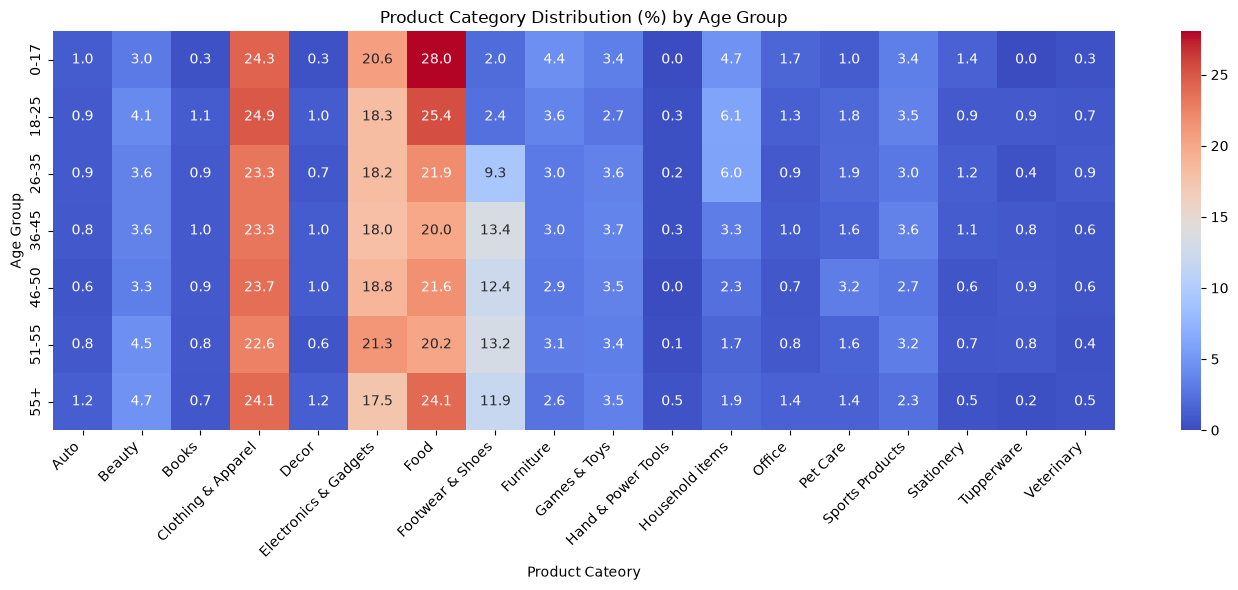

In [61]:
product_age_group_pct = pd.crosstab(
    df_copy['Age Group'],
    df_copy['Product_Category'],
    normalize='index'
).mul(100).round(2)

print(product_age_group_pct, '\n')

plt.figure(figsize=(14, 6))

sns.heatmap(
    product_age_group_pct,
    annot=True,
    fmt='.1f',
    cmap='coolwarm'
)

plt.title('Product Category Distribution (%) by Age Group')
plt.xlabel('Product Cateory')
plt.ylabel('Age Group')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Bivariate Analysis: Occupation and Customer Name**

In [62]:
occupation_gender = (
    df_copy.groupby(['Occupation', 'Gender'])['Cust_name']
    .nunique()
    .unstack(fill_value=0)
)

occupation_gender['Total'] = occupation_gender.sum(axis=1)

occupation_gender = occupation_gender.sort_values(
    'Total',
    ascending=False
)

occupation_gender_pct = (
    occupation_gender[['F', 'M']]
    .div(occupation_gender['Total'], axis=0)
    .mul(100)
    .round(2)
)

print("Total Count of Occupation by Gender:")
print(occupation_gender, '\n')
print("=====" * 10)
print("\nPercentages of Occupation by Gender: ")
print(occupation_gender_pct)

Total Count of Occupation by Gender:
Gender             F    M  Total
Occupation                      
IT Sector        633  352    985
Healthcare       600  310    910
Aviation         589  279    868
Banking          547  236    783
Govt             436  192    628
Hospitality      360  180    540
Media            334  170    504
Automobile       289  145    434
Chemical         293  131    424
Lawyer           284  137    421
Retail           290  110    400
Food Processing  245  105    350
Construction     226  102    328
Textile          199   99    298
Agriculture      174   70    244 


Percentages of Occupation by Gender: 
Gender              F     M
Occupation                 
IT Sector       64.26 35.74
Healthcare      65.93 34.07
Aviation        67.86 32.14
Banking         69.86 30.14
Govt            69.43 30.57
Hospitality     66.67 33.33
Media           66.27 33.73
Automobile      66.59 33.41
Chemical        69.10 30.90
Lawyer          67.46 32.54
Retail          72.50 27.

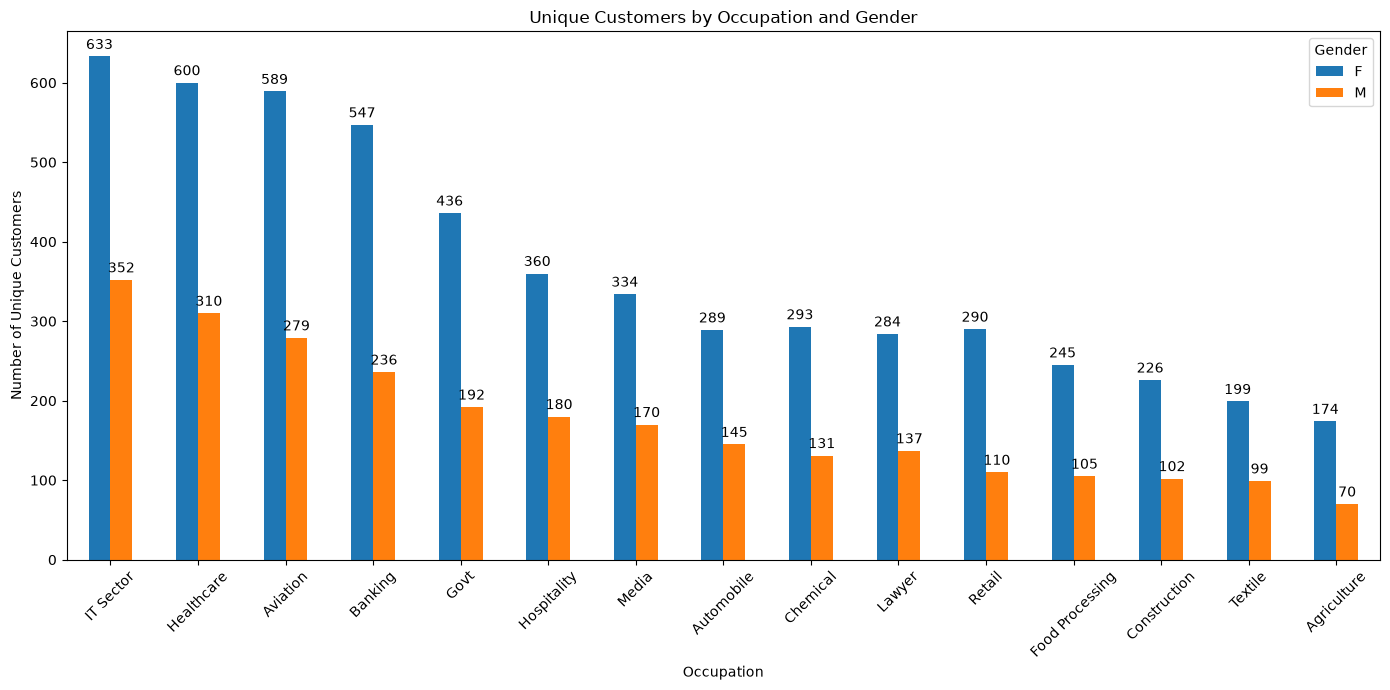

In [64]:
ax = occupation_gender[['F', 'M']].plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Unique Customers by Occupation and Gender')
plt.xlabel('Occupation')
plt.ylabel('Number of Unique Customers')
plt.legend(title='Gender')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

**Bivariate Analysis: Zone and Customer Name**

In [66]:
zone_gender = (
    df_copy.groupby(['Zone', 'Gender'])['Cust_name']
    .nunique()
    .unstack(fill_value=0)
)

zone_gender['Total'] = zone_gender.sum(axis=1)

zone_gender = zone_gender.sort_values(
    'Total',
    ascending=False
)

zone_gender_pct = (
    zone_gender[['F', 'M']]
    .div(zone_gender['Total'], axis=0)
    .mul(100)
    .round(2)
)

print("Unique Customer Count by Zone and Gender:")
print(zone_gender, '\n')
print("=====" * 10)
print("\nPercentages of Zone by Gender: ")
print(zone_gender_pct)

Unique Customer Count by Zone and Gender:
Gender       F    M  Total
Zone                      
Central   1076  686   1762
Southern   898  531   1429
Western    784  382   1166
Northern   632  345    977
Eastern    449  209    658 


Percentages of Zone by Gender: 
Gender       F     M
Zone                
Central  61.07 38.93
Southern 62.84 37.16
Western  67.24 32.76
Northern 64.69 35.31
Eastern  68.24 31.76


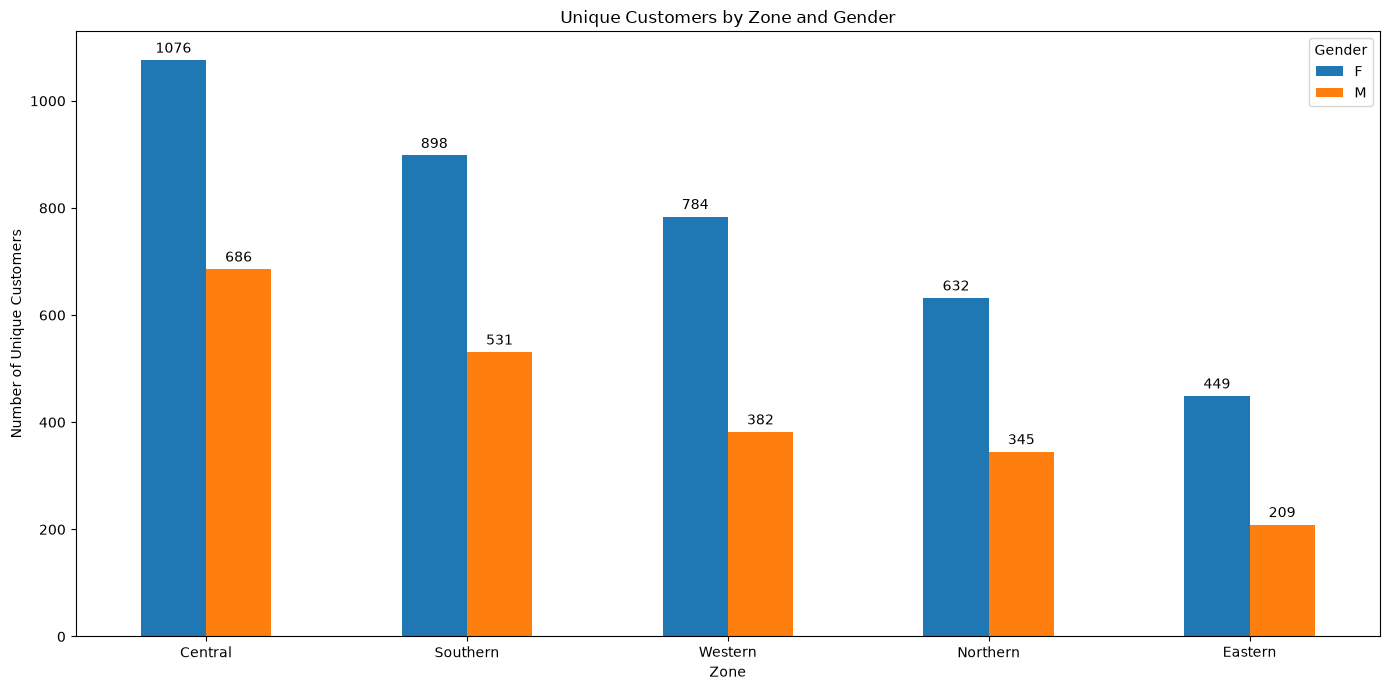

In [67]:
ax = zone_gender[['F', 'M']].plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Unique Customers by Zone and Gender')
plt.xlabel('Zone')
plt.ylabel('Number of Unique Customers')
plt.legend(title='Gender')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

**Bivariate Analysis: State and Customer Name**

In [68]:
state_gender = (
    df_copy.groupby(['State', 'Gender'])['Cust_name']
    .nunique()
    .unstack(fill_value=0)
)

state_gender['Total'] = state_gender.sum(axis=1)

state_gender = state_gender.sort_values(
    'Total',
    ascending=False
)

state_gender_pct = (
    state_gender[['F', 'M']]
    .div(state_gender['Total'], axis=0)
    .mul(100)
    .round(2)
)

print("Unique Customer Count by State and Gender:")
print(state_gender, '\n')
print("=====" * 10)
print("\nPercentages of State by Gender: ")
print(state_gender_pct)

Unique Customer Count by State and Gender:
Gender              F    M  Total
State                            
Uttar Pradesh     926  437   1363
Maharashtra       717  329   1046
Karnataka         629  320    949
Delhi             525  280    805
Madhya Pradesh    456  234    690
Andhra Pradesh    421  211    632
Himachal Pradesh  339  171    510
Haryana           277  118    395
Bihar             268  124    392
Kerala            265  123    388
Gujarat           267  111    378
Jharkhand         235  104    339
Uttarakhand       202   98    300
Rajasthan         136   75    211
Punjab            124   60    184
Telangana          74   46    120 


Percentages of State by Gender: 
Gender               F     M
State                       
Uttar Pradesh    67.94 32.06
Maharashtra      68.55 31.45
Karnataka        66.28 33.72
Delhi            65.22 34.78
Madhya Pradesh   66.09 33.91
Andhra Pradesh   66.61 33.39
Himachal Pradesh 66.47 33.53
Haryana          70.13 29.87
Bihar            68

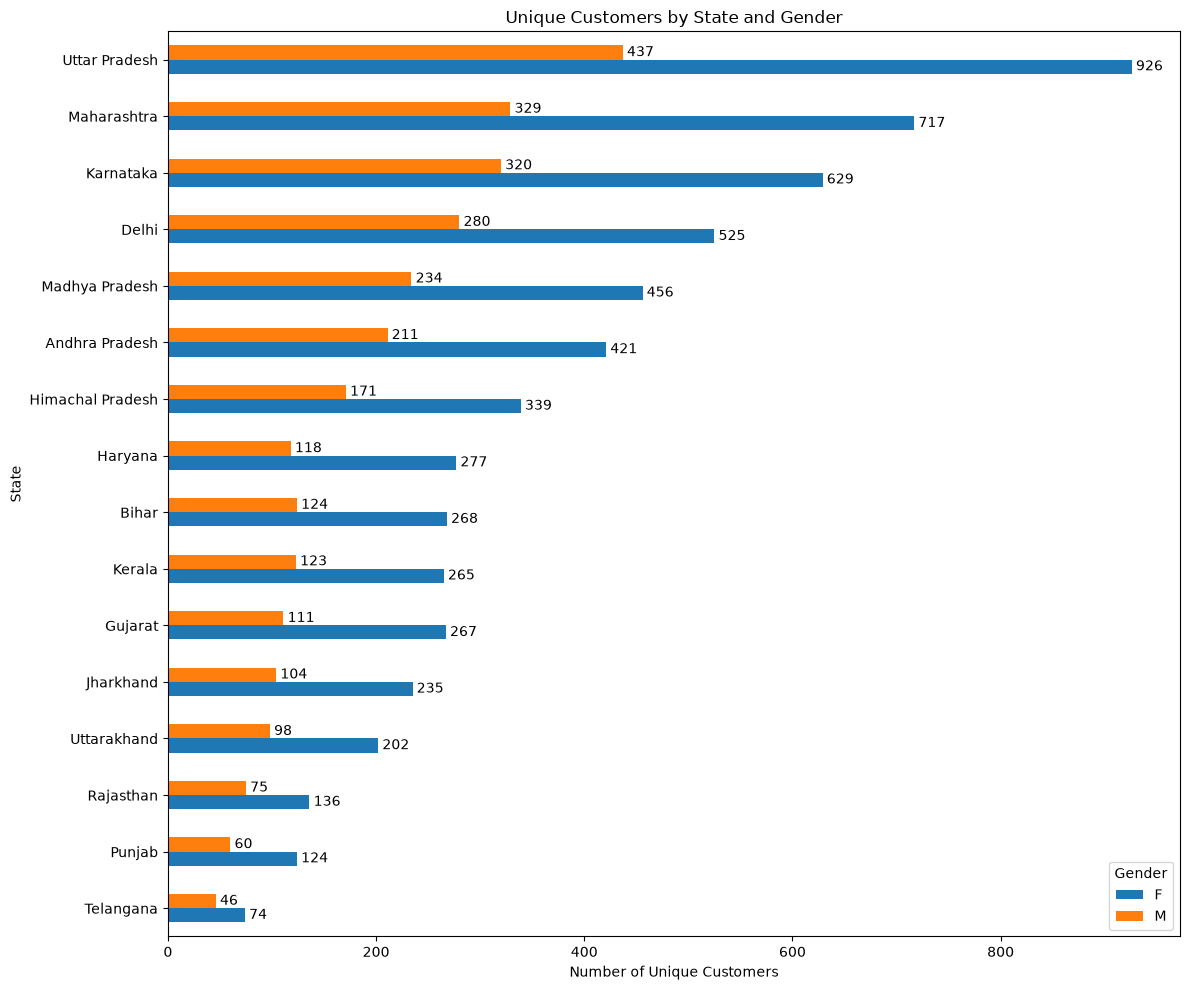

In [69]:
state_gender_sorted = state_gender.sort_values(
    'Total',
    ascending=True
)

ax = state_gender_sorted[['F', 'M']].plot(
    kind='barh',
    figsize=(12, 10)
)

plt.title('Unique Customers by State and Gender')
plt.xlabel('Number of Unique Customers')
plt.ylabel('State')
plt.legend(title='Gender')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

**Bivariate Analysis: Product Category vs Amount**

Product Category Sales: 
Product_Category
Office                      81,936.00
Veterinary                 112,702.00
Hand & Power Tools         405,618.00
Pet Care                   482,277.00
Decor                      730,360.00
Books                    1,061,478.00
Tupperware               1,155,642.00
Household items          1,569,337.00
Stationery               1,676,051.50
Beauty                   1,959,484.00
Auto                     1,992,904.49
Sports Products          3,635,933.00
Games & Toys             4,331,694.00
Furniture                5,456,329.49
Electronics & Gadgets   15,607,657.00
Footwear & Shoes        15,656,654.45
Clothing & Apparel      16,484,472.00
Food                    33,979,579.50
Name: Amount, dtype: float64



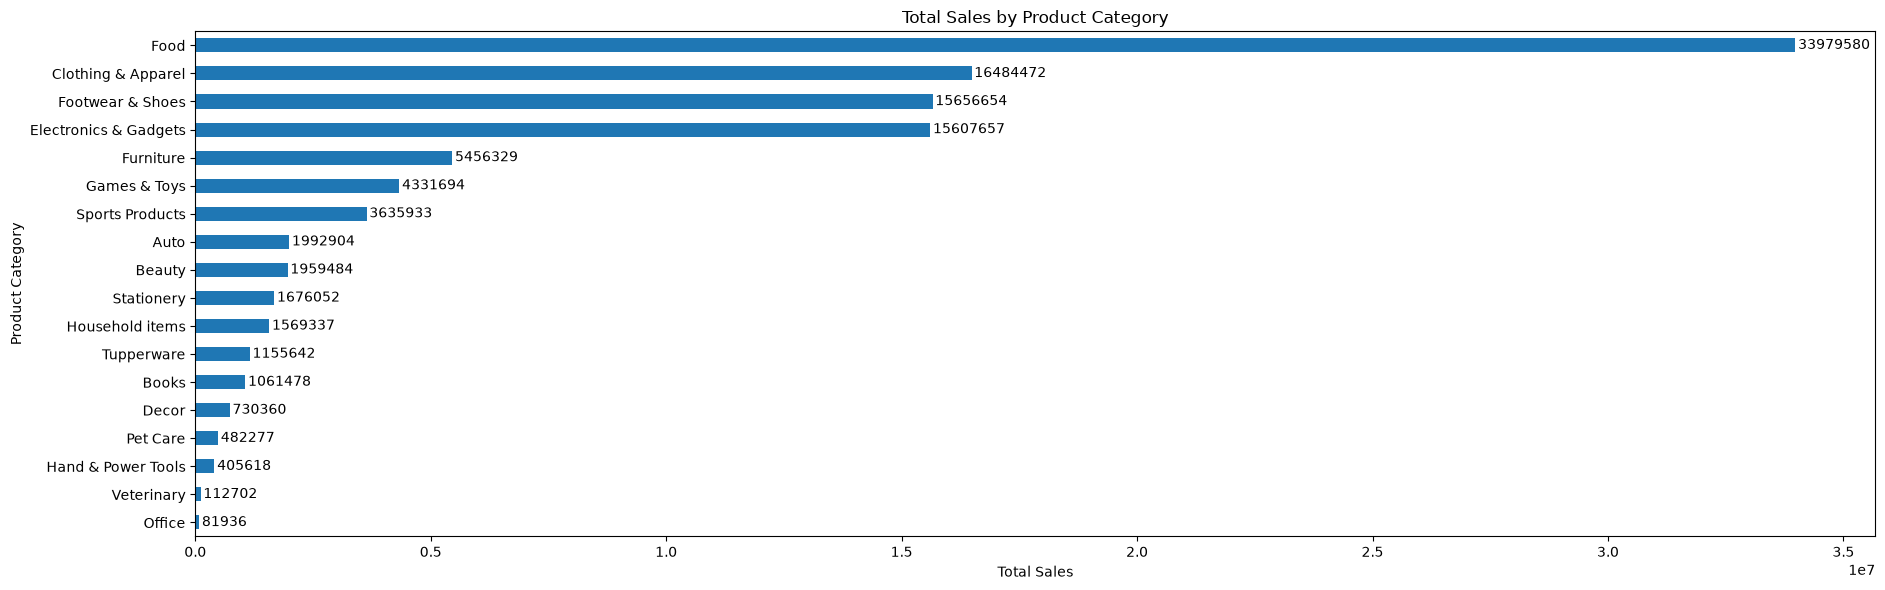

In [73]:
product_category_sales = (
    df_copy.groupby('Product_Category')['Amount']
    .sum()
    .sort_values(ascending=True)
)

print('Product Category Sales: ')
print(product_category_sales)
print()

ax = product_category_sales.plot(
    kind='barh',
    figsize=(19,6)

)

plt.title('Total Sales by Product Category')
plt.xlabel('Total Sales')
plt.ylabel('Product Category')

for container in ax.containers:
  ax.bar_label(
      container,
      fmt='%.0f',
      padding=2
  )


plt.tight_layout()
plt.show()

**Bivariate Analysis: Occupation vs Amount**

Average Purchase Amount by Occupation:
Occupation
Govt              9,973.32
Media             9,883.57
Chemical          9,803.90
Aviation          9,625.66
Food Processing   9,623.33
Retail            9,547.25
Automobile        9,512.06
Banking           9,484.80
Lawyer            9,381.67
IT Sector         9,349.46
Healthcare        9,257.52
Textile           9,203.60
Agriculture       9,166.66
Hospitality       9,077.14
Construction      8,691.50
Name: Amount, dtype: float64



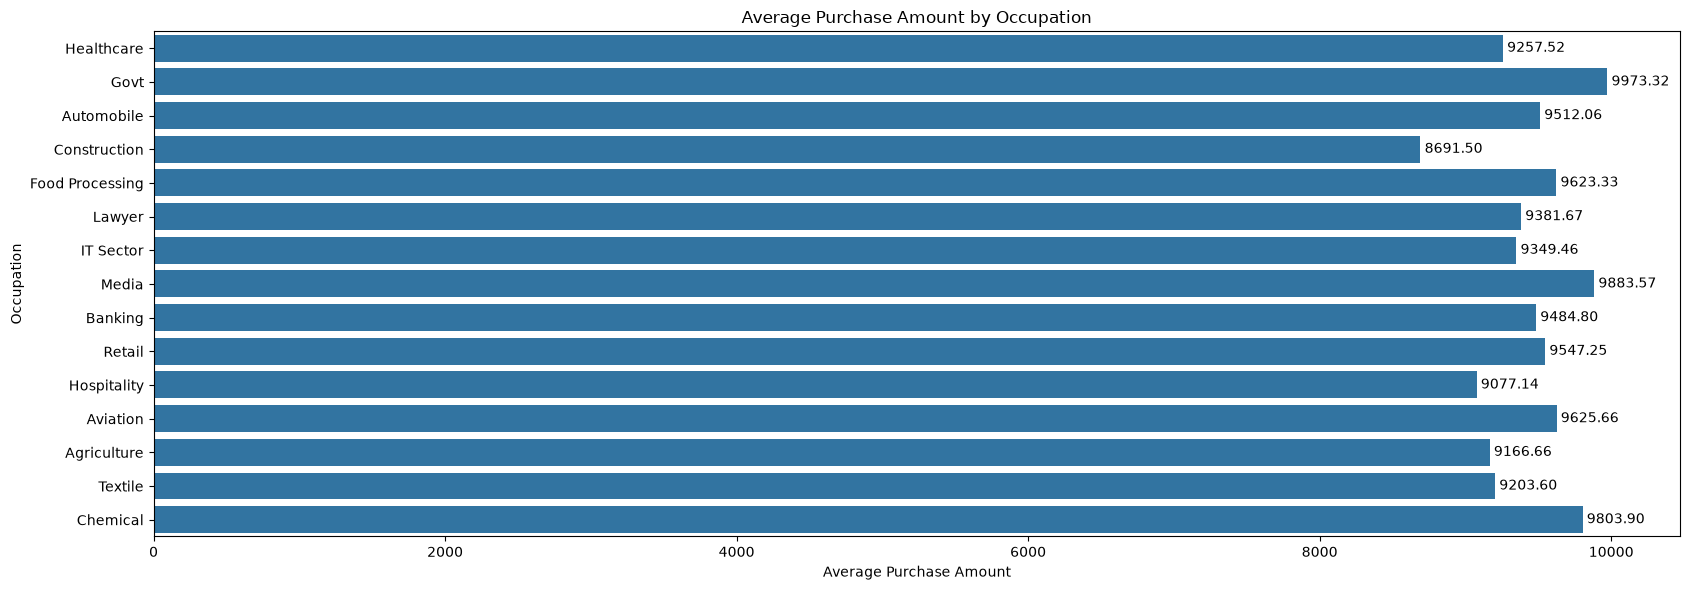

In [74]:
occupation_amount = (
    df_copy.groupby('Occupation')['Amount']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print('Average Purchase Amount by Occupation:')
print(occupation_amount)
print()

plt.figure(figsize=(17, 6))

ax = sns.barplot(
    data=df_copy,
    x='Amount',
    y='Occupation',
    estimator='mean',
    errorbar=None
)

plt.title('Average Purchase Amount by Occupation')
plt.xlabel('Average Purchase Amount')
plt.ylabel('Occupation')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

**Customer Segmentation Analysis**

In [75]:
segment_cols = [
    'Age Group',
    'Occupation',
    'Zone',
    'Marital_Status'
]

for col in segment_cols:

    segment_sales = (
        df_copy.groupby(col)['Amount']
        .sum()
        .sort_values(ascending=False)
    )

    print(f'Total Sales by {col}:')
    print(segment_sales.round(2))
    print('=' * 50)

Total Sales by Age Group:
Age Group
26-35   42,613,278.44
36-45   22,181,889.49
18-25   17,235,530.00
46-50    9,278,997.00
51-55    8,270,487.00
55+      4,100,274.50
0-17     2,699,653.00
Name: Amount, dtype: float64
Total Sales by Occupation:
Occupation
IT Sector         14,828,247.00
Healthcare        13,034,587.49
Aviation          12,599,994.00
Banking           10,803,188.95
Govt               8,517,212.00
Hospitality        6,372,152.50
Media              6,295,832.99
Automobile         5,383,828.00
Chemical           5,313,713.50
Lawyer             4,981,665.00
Retail             4,783,170.00
Food Processing    4,070,670.00
Construction       3,589,588.00
Textile            3,221,261.00
Agriculture        2,584,999.00
Name: Amount, dtype: float64
Total Sales by Zone:
Zone
Central    41,685,810.95
Southern   26,642,245.48
Western    18,394,480.00
Northern   12,616,448.00
Eastern     7,041,125.00
Name: Amount, dtype: float64
Total Sales by Marital_Status:
Marital_Status
0   62,1

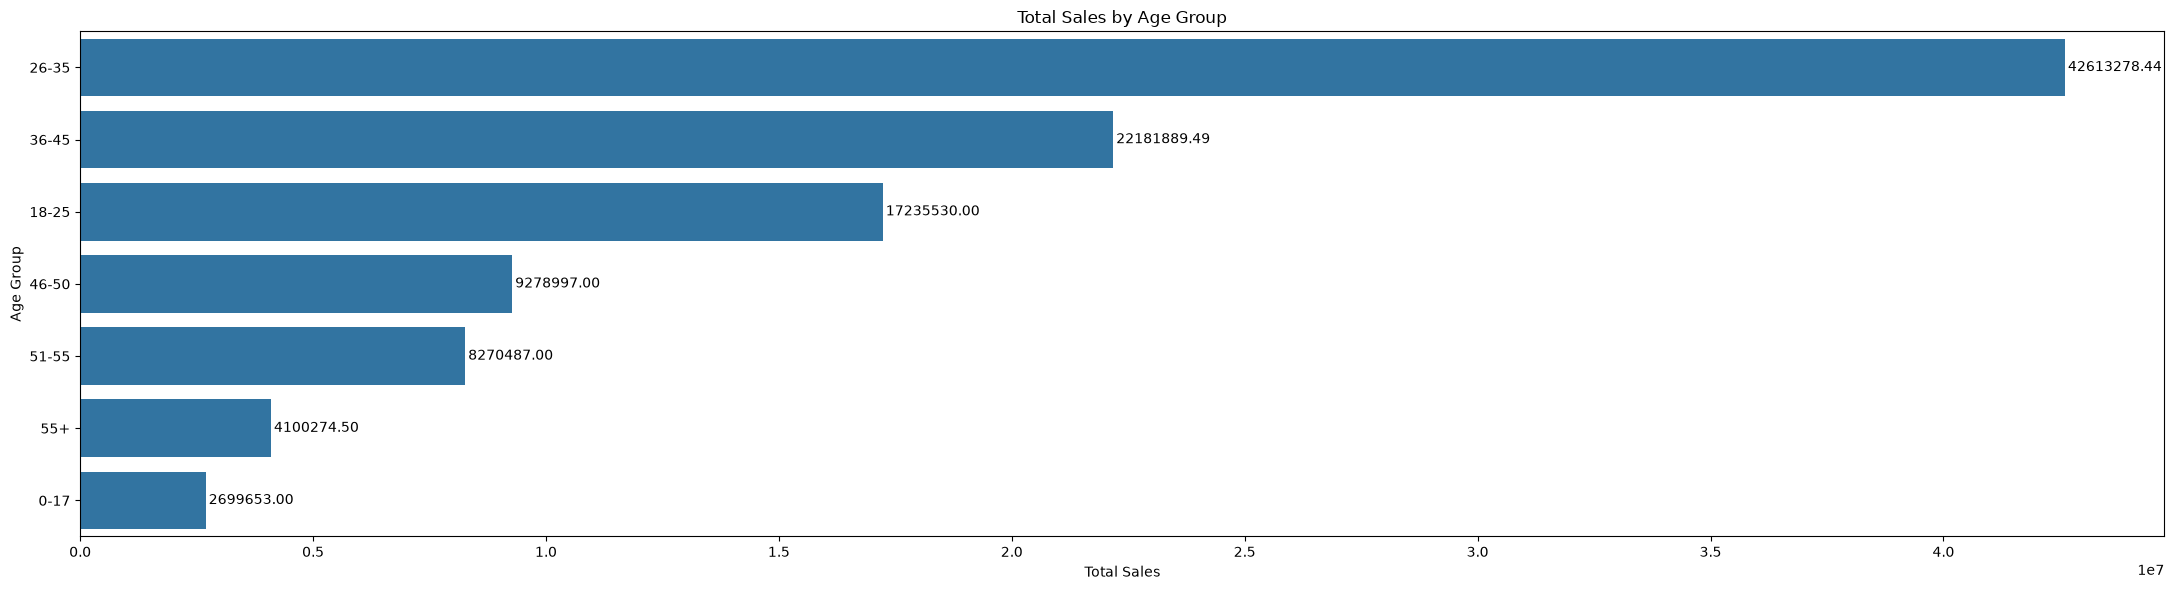

In [76]:
segment_sales = (
    df_copy.groupby('Age Group')['Amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(22, 6))

ax = sns.barplot(
    x=segment_sales.values,
    y=segment_sales.index,
    errorbar=None
)

plt.title('Total Sales by Age Group')
plt.xlabel('Total Sales')
plt.ylabel('Age Group')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2)

plt.tight_layout()
plt.show()

**Correlation Analysis**

,User_ID,Age,Marital_Status,Orders,Amount
User_ID,1.00,0.02,0.00,-0.02,-0.01
Age,0.02,1.00,-0.01,0.01,0.03
Marital_Status,0.00,-0.01,1.00,-0.00,-0.02
Orders,-0.02,0.01,-0.00,1.00,-0.01
Amount,-0.01,0.03,-0.02,-0.01,1.00


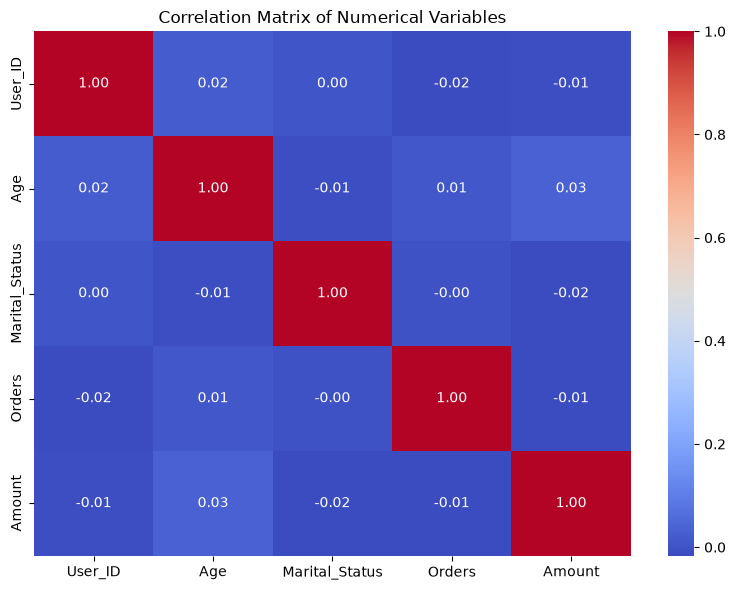

In [77]:
num_cols_corr_matrix = df_copy.select_dtypes(include='number').corr()
display(num_cols_corr_matrix)
print('\n')

plt.figure(figsize=(8, 6))

sns.heatmap(
    num_cols_corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

# **1. Customer Profile Questions:**

### **What is the distribution of customers by gender?**

- The dataset consists predominantly of female customers, with **7,838 female customers**, compared with **3,405 male customers**. This indicates that female customers make up the larger share of the customer base in the dataset.

### **Which age groups represent the largest share of customers?**

- The **26–35 age group** represents the largest share of customers, accounting for **40.36%** of the dataset, followed by the **36–45 age group** at **20.32%**. The remaining age groups are **18–25 with 1,878 customers**, **46–50 with 987 customers**, **51–55 with 831 customers**, **55+ with 428 customers**, and **0–17 with 298 customers**.

This indicates that the customer base is concentrated among **young adults, particularly those aged 26–35**.

### **What is the distribution of customers by marital status?**

- The dataset contains **6,518 unmarried customers** and **4,725 married customers**. Among unmarried customers, **70.19% are female and 29.81% are male**. Among married customers, **69.06% are female and 30.94% are male**.

- This shows that **female customers make up the majority of both the unmarried and married customer groups**, while male customers represent a smaller share in both groups.

### **Which occupations have the most customers?**

- The **IT Sector** has the largest number of customers, with **633 female customers and 352 male customers**, for a total of **985 customers**. This is followed by **Healthcare**, with **600 female and 310 male customers**, for a total of **910 customers**. **Aviation** ranks third, with **589 female and 279 male customers**, for a total of **858 customers**.

- This indicates that the **IT Sector, Healthcare, and Aviation** have the largest customer populations among the occupations in the dataset.

### **Which states/zones have the most customers?**

- The top five states by number of customers are:

  1. **Uttar Pradesh — 1,363 customers**
  2. **Maharashtra — 1,046 customers**
  3. **Karnataka — 949 customers**
  4. **Delhi — 805 customers**
  5. **Madhya Pradesh — 690 customers**

- Among the zones, the **Central Zone** has the largest number of customers, with **1,762 customers**, followed by the **Southern Zone with 1,429**, **Western Zone with 1,166**, **Northern Zone with 977**, and **Eastern Zone with 658**.

- This indicates that the customer base is most concentrated in the **Central Zone**, with Uttar Pradesh being the state with the largest customer count.

# **2. Sales Performance Questions:**

### **What is the distribution of Amount?**

* The distribution of transaction amounts is **slightly right-skewed**, with a skewness of 0.55. The mode is 7,907, meaning that 7,907 is the most frequently occurring transaction amount. Transaction amounts range from 188 to 23,952.

### **Which product categories generate the most sales?**

* The top five product categories by total sales are **Food**, with 33,979,579.50 in total sales, followed by **Clothing & Apparel** with 16,484,472.00, **Footwear & Shoes** with 15,656,654.45, **Electronics & Gadgets** with 15,607,657.00, and **Furniture** with 5,456,329.49.

### **Which age groups contribute the most sales?**

* The top three age groups by total sales are **26–35**, with 42,613,278.44 in total sales, followed by **36–45** with 22,181,889.49, and **18–25** with 17,235,530.00.


# **3. Customer Purchasing Behavior Questions:**

### **Do some age groups place more orders than others?**
- Yes. The 26–35 age group has the highest total number of orders, with 11,381 orders, while the 0–17 age group has the lowest, with 690 orders.

### **Which occupations have the highest average purchase amount?**
- The top 5 occupations with the highest average purchase amounts are Government (9,973.32), Media (9,883.57), Chemical (9,803.90), Aviation (9,625.66), and Food Processing (9,623.33).

### **Which customer segments generate the highest total sales?**
- Age Group: The 26–35 age group generated the highest total sales at 42,613,278.44, followed by the 36–45 age group at 22,181,889.49.

- Occupation: The IT Sector generated the highest total sales at 14,828,247.00, followed by Healthcare at 13,034,587.49 and Aviation at 12,599,994.00.

- Zone: The Central zone generated the highest total sales at 41,685,810.95, followed by the Southern zone at 26,642,245.48.

- Marital Status: Unmarried customers (0) generated the highest total sales at 62,165,833.94, compared with 44,214,275.49 for married customers (1).

- Overall, the 26–35 age group, IT Sector occupation, Central zone, and unmarried customers generated the highest total sales within their respective customer segments.


# **4. Product Performance Questions:**

### **Which product categories generate the highest total Amount?**
- The Food category generated the highest total Amount, followed by Clothing & Apparel, Footwear & Shoes, Electronics & Gadgets, and Furniture.

### **Are certain product categories more popular among particular age groups?**
- Yes. Food is the most represented product category among customers aged 0–17 and 18–25, accounting for 28.04% and 25.45% of their respective product-category distributions. For customers aged 26 and above, Clothing & Apparel is the most represented category, ranging from 22.62% to 24.07%. This suggests that product-category distributions vary somewhat across age groups, with Food having the highest share among younger customers and Clothing & Apparel having the highest share among older customers.

# **5. Business Recommendations:**

- Based on the analysis, the **26–35 age group** is a customer group that the company should pay particular attention to. This age group generated the **highest total sales** and also represents the **largest share of customers, at 40.36%**. In terms of product categories, **Food** and **Clothing & Apparel** have the highest representation among customers in this age group. These findings suggest that the company could prioritize this customer group and these product categories when developing targeted marketing strategies.
